In [1]:
%load_ext autoreload 
%autoreload 2
%matplotlib inline
import json, os, cv2
from pathlib import Path
import numpy as np
import pandas as pd
from tqdm import tqdm
from scipy.interpolate import interp1d
from scipy import signal
from scipy.signal import find_peaks
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
from sklearn.cluster import KMeans
import matplotlib.colors as mcolors
from matplotlib.backends.backend_pdf import PdfPages
from matplotlib.gridspec import GridSpec
import glob 
import seaborn as sns
from brokenaxes import brokenaxes
from frechetdist import frdist
from scipy.ndimage import gaussian_filter
from dipy.segment.metricspeed import AveragePointwiseEuclideanMetric
import ast
import scipy.stats as stats


import sys
sys.path.insert(0, 'C:/Users/nlab/Documents/GitHub/obstacle_avoidance')

import warnings
warnings.filterwarnings('ignore')
from streamline_clustering.clustering import pair_elements,create_streamlines
from src.base import BaseInput
from src.topcam import Topcam
from src.utils.auxiliary import find_index_in_list,flatten_series
from pipeline.helper_functions import list_columns,interpolate_array,flatten_list_of_arrays,calculate_quartiles,create_df_by_type,split_range_into_parts,get_mean_of_df,get_median_of_df,drop_nans_in_columns,create_consective_df_new,assign_date_index,symmetrize_y_axis,edge_outliers,create_df_by_type_nostart,find_consecutive_repeats,largest_sequentially_increasing_by_one_subarray,create_color_dict,smooth,create_monotonic_array,correct_trace
from pipeline.oa_calculations import distance_calcs,heading_calcs,cluster_obstacle,calculate_distances,df_tortuosity,calculate_speed,deveation,lateral_error,start,redo_ts_trace,compute_tortuosity,angular_velocity_head,turn_direction,turn_to_obstacle,get_head_angle,head_angle_velocity,intial_lateral_error,avg_lateral_error,check_trial_for_obstalce_cross_df,distance_at_head_turn,zero_out_angle_target_port,angular_velocity_head_corner
from pipeline.oa_plotting_funcs import plot_arena,plot_orginal_obstacle,plot_obstacle_from_row
from pipeline.batch_process_oa import plot_oa

Loading DLC 2.3.0...
DLC loaded in light mode; you cannot use any GUI (labeling, relabeling and standalone GUI)


In [8]:

font = {'family' : 'arial',
        'weight' : 'normal',
        'size'   : 24}

plt.rc( 'font',**font);

In [2]:
def distance_at_head_turn_2(df):
    for ind,row in df.iterrows():
        peaks, prop = find_peaks(np.abs(row.head_angle_velocity[:int(row.obstacle_ind)]), width=2,height=(3,12))
        if len(peaks) == 0:
            df.at[ind,'distance_at_head_turn_2'] = np.nan
            df.at[ind,'distance_at_head_turn_2_index'] = np.nan
            df.at[ind,'distance_at_head_turn_2_indexs'] = np.nan
            df.at[ind,'angle_at_head_turn_2'] = np.nan
            df.at[ind,'num_turn'] = 0
        else:
            max_peak = peaks[prop['peak_heights'].argmax()]
  
            df.at[ind,'distance_at_head_turn_2'] = row.ts_distance_from_edge[:int(row.obstacle_ind)][max_peak]
            df.at[ind,'distance_at_head_turn_2_index'] = max_peak
            df.at[ind,'distance_at_head_turn_2_indexs'] = np.array(peaks).astype(object)
            df.at[ind,'angle_at_head_turn_2'] = row.ts_angle_to_corner[:int(row.obstacle_ind)][max_peak]
            df.at[ind,'num_turn'] = len(peaks)
def towards_away_turns(df):
    for ind,row in df.iterrows():
        pos_peaks, pos_prop = find_peaks(row.head_corner_angle_velocity[:int(row.obstacle_ind)], width=1,height=(2,12))
        neg_peaks, neg_prop = find_peaks((row.head_corner_angle_velocity[:int(row.obstacle_ind)])*-1, width=1,height=(2,12))
        if len(pos_peaks) == 0:
            df.at[ind,'towards_num_turn'] = 0
        elif len(neg_peaks) == 0: 
            df.at[ind,'away_num_turn'] = 0  
        else:
            df.at[ind,'towards_num_turn'] = len(pos_peaks)
            df.at[ind,'away_num_turn'] = len(neg_peaks)
def right_left_turns(df):
    for ind,row in df.iterrows():
        pos_peaks, pos_prop = find_peaks(row.head_angle_velocity[:int(row.obstacle_ind)], width=2,height=(3,12))
        neg_peaks, neg_prop = find_peaks(row.head_angle_velocity[:int(row.obstacle_ind)]*-1, width=2,height=(3,12))
        
        if row.odd == 'right':
            df.at[ind,'right_num_turn'] = len(neg_peaks)
            df.at[ind,'right_turns_distances'] = row.ts_distance_from_edge[:int(row.obstacle_ind)][neg_peaks]
            df.at[ind,'left_num_turn'] = len(pos_peaks)
            df.at[ind,'left_turns_distances'] = row.ts_distance_from_edge[:int(row.obstacle_ind)][pos_peaks]
        elif row.odd == 'left':
            df.at[ind,'right_num_turn'] = len(pos_peaks)
            df.at[ind,'right_turns_distances'] = row.ts_distance_from_edge[:int(row.obstacle_ind)][pos_peaks]
            df.at[ind,'left_num_turn'] = len(neg_peaks)
            df.at[ind,'left_turns_distances'] = row.ts_distance_from_edge[:int(row.obstacle_ind)][neg_peaks]

dark (['J704RT', 'J704NN', 'J704LT', 'J704LN', 'G8CK1RT', 'G8CK1LT',
       'G8CK1TT', 'G8CK1LN', 'G8CKRT', 'G8CKLT', 'G8CKTT', 'G8CKRN',
       'G8CKLN'], dtype=object)

light(['J701LT', 'J701RT', 'J701NN', 'J701RN', 'G8CK1RT', 'G8CK1LT',
       'G8CK1TT', 'G8CK1LN', 'G8CKRT', 'G8CKLT', 'G8CKTT', 'G8CKRN',
       'G8CKLN'], dtype=object)

In [255]:
light = pd.read_hdf(r"D:\obstacle_avoidance\metadata\SFN\data\light_092524_oa.h5")
dark = pd.read_hdf(r"D:\obstacle_avoidance\metadata\SFN\data\dark_092524_oa.h5")
joint = pd.concat([light,dark])
heading_calcs(joint)
get_head_angle(joint)
head_angle_velocity(joint)
angular_velocity_head_corner(joint)
distance_at_head_turn_2(joint)
towards_away_turns(joint)
right_left_turns(joint)
#con_df = create_consective_df_new(joint)

long_nostart,short_nostart,middle_nostart = create_df_by_type_nostart(joint)
#long_con_nostart,short_con_nostart,middle_con_nostart = create_df_by_type_nostart(con_df)

long,short,middle = create_df_by_type(joint)
#long_con,short_con,middle_con = create_df_by_type(con_df)

corner
port


In [601]:
oa_session = plot_oa(r"D:\obstacle_avoidance\metadata\J675\oa_monle.json",'blank')
oa_session.gather_session_df('obstacle',6)
mon = oa_session.df
get_head_angle(mon)
head_angle_velocity(mon)
turn_direction(mon)
turn_to_obstacle(mon)
mon = drop_nans_in_columns(mon,'obstacle_ind')
angular_velocity_head_corner(mon)
towards_away_turns(mon)
distance_at_head_turn_2(mon)
heading_calcs(mon)
right_left_turns(mon)
#right_left_ratio(mon)
mon['task_com'] = 'mon'
mon_long_nostart,mon_short_nostart,mon_middle_nostart = create_df_by_type_nostart(mon)

6
corner
port


In [602]:
oa_session = plot_oa(r"D:\obstacle_avoidance\metadata\J675\oa_J675__late.json",'blank')
oa_session.gather_session_df('obstacle',6)
con = oa_session.df
get_head_angle(con)
head_angle_velocity(con)
turn_direction(con)
turn_to_obstacle(con)
con = drop_nans_in_columns(con,'obstacle_ind')
angular_velocity_head_corner(con)
towards_away_turns(con)
distance_at_head_turn_2(con)
heading_calcs(con)
right_left_turns(con)
#right_left_ratio(con)
con['task_com'] = 'oa'
con_long_nostart,con_short_nostart,con_middle_nostart = create_df_by_type_nostart(con)

6
corner
port


In [ ]:
for ani,ani_df in dark.groupby(['animal']):
    ani_dark_dists = flatten_list_of_arrays(ani_df.ts_distance_from_edge.to_list())
    ani_dark_dists = ani_dark_dists[np.where((ani_dark_dists>=0))]
    sns.kdeplot(ax = ax,data = ani_dark_dists,color = 'tab:blue', alpha = .25 )

In [703]:
counts

array([5872, 2842, 2471, 1511, 1023,  989,  982, 1036, 1069, 1104,  898,
        687,  608,  771,  664,  637,  459,  482,  481,  531,  591,  584,
        320,  283,  212,  255,  206,   56,   18,   55], dtype=int64)

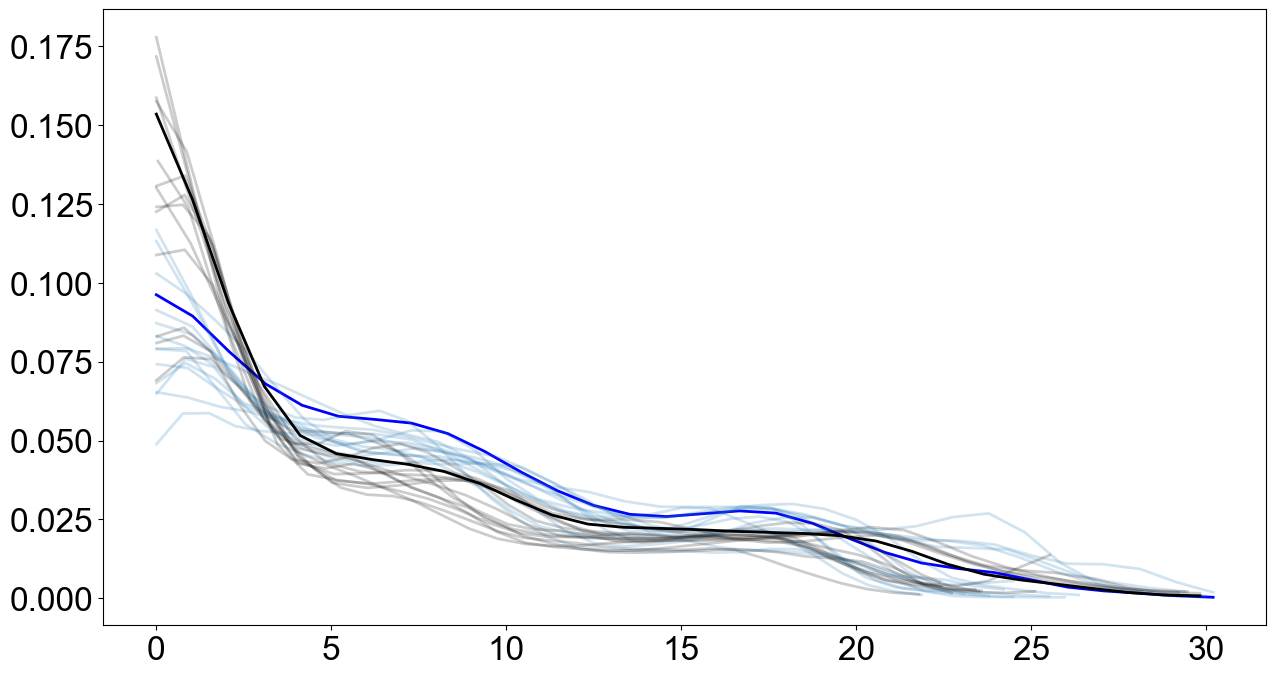

In [702]:
data = pd.concat([joint])
data = data[data.turn_to_obstacle == 'towards']
fig,ax = plt.subplots(1,1,figsize=(15,8),sharey =True)
light = data[data.task =='oa']
light_dist = flatten_list_of_arrays(light.ts_distance_from_edge.to_numpy())
light_dist = light_dist[np.where((light_dist>=0))]
counts, bins = np.histogram(light_dist, bins=30)
ax.plot(bins[:-1], smooth(counts/sum(counts)), 'b-', linewidth=2, label='Line')
#ax[0].fill_between(bins[:-1], counts, alpha=0.5, label='Fill')

for ani,ani_df in light.groupby(['animal']):
    ani_light_dists = flatten_list_of_arrays(ani_df.ts_distance_from_edge.to_numpy())
    ani_light_dists = ani_light_dists[np.where((ani_light_dists>=0))]
    counts, bins = np.histogram(ani_light_dists, bins=30)
    ax.plot(bins[:-1], smooth(counts/sum(counts)), 'b-', linewidth=2, label='Line', alpha=0.2,color = 'tab:blue')
    #ax[0].fill_between(bins[:-1], counts, alpha=0.2, label='Fill')

dark = data[data.task =='oadark']
dark_dist = flatten_list_of_arrays(dark.ts_distance_from_edge.to_numpy())
dark_dist = dark_dist[np.where((dark_dist>=0))]
counts, bins = np.histogram(dark_dist, bins=30)
ax.plot(bins[:-1], smooth(counts/sum(counts)), 'b-', linewidth=2, label='Line',color = 'black')
#ax[0].fill_between(bins[:-1], counts, alpha=0.5, label='Fill')

for ani,ani_df in dark.groupby(['animal']):
    ani_dark_dists = flatten_list_of_arrays(ani_df.ts_distance_from_edge.to_numpy())
    ani_dark_dists = ani_dark_dists[np.where((ani_dark_dists>=0))]
    counts, bins = np.histogram(ani_dark_dists, bins=30)
    ax.plot(bins[:-1], smooth(counts/sum(counts)), 'b-', linewidth=2, label='Line', alpha=0.2,color = 'black')

In [1]:
data = joint
fig,ax = plt.subplots(1,1,figsize=(15,8),sharey =True)
light = data[data.task =='oa']
light_dist = flatten_list_of_arrays(light.ts_distance_from_edge.to_list())
light_dist = light_dist[np.where((light_dist>=0))]
 
sns.kdeplot(ax = ax,data = light_dist,color = 'tab:blue')

for ani,ani_df in light.groupby(['animal']):
    ani_light_dists = flatten_list_of_arrays(ani_df.ts_distance_from_edge.to_list())
    ani_light_dists = ani_light_dists[np.where((ani_light_dists>=0))]
    sns.kdeplot(ax = ax,data = ani_light_dists,color = 'tab:blue', alpha = .2 )

dark = data[data.task =='oadark']
dark_dist = flatten_list_of_arrays(dark.ts_distance_from_edge.to_list())
dark_dist = dark_dist[np.where((dark_dist>=0))]

sns.kdeplot(ax = ax,data = dark_dist,color = 'black')

for ani,ani_df in dark.groupby(['animal']):
    ani_dark_dists = flatten_list_of_arrays(ani_df.ts_distance_from_edge.to_list())
    ani_dark_dists = ani_dark_dists[np.where((ani_dark_dists>=0))]
    sns.kdeplot(ax = ax,data = ani_dark_dists,color = 'black', alpha = .2,linestyle ='none' )

ax.set_xticks([0,10,20,30])

ax.set_ylabel('proportion')
fig.text(0.5, 0.03, 'distance to obstacle (cm)', ha='center')


NameError: name 'joint' is not defined

Text(0.5, 0.03, 'distance to obstacle (cm)')

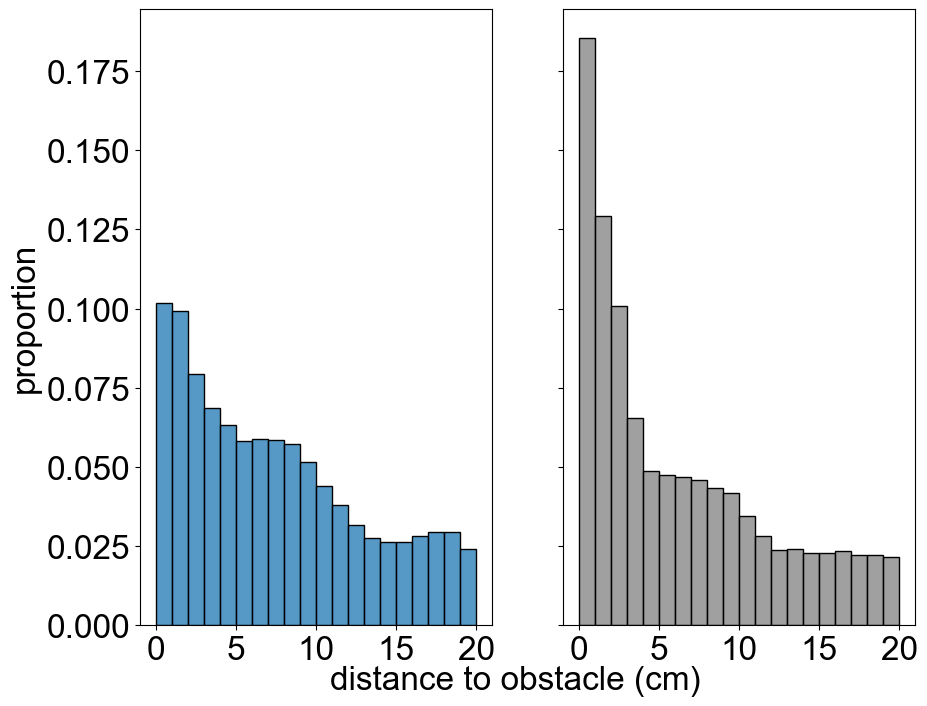

In [645]:
data = pd.concat([joint])
data = data[data.turn_to_obstacle == 'towards']
dark = data[data.task =='oadark']
light = data[data.task =='oa']

fig,ax = plt.subplots(1,2,figsize=(10,8),sharey =True)

light_dist = flatten_list_of_arrays(light.ts_distance_from_edge.to_list())
light_dist = light_dist[np.where((light_dist>=0))]
light_dist = light_dist[np.where((light_dist<=20))]
dark_dist = flatten_list_of_arrays(dark.ts_distance_from_edge.to_list())
dark_dist = dark_dist[np.where((dark_dist>=0))]
dark_dist = dark_dist[np.where((dark_dist<=20))]

sns.histplot(data = light_dist,ax =ax[0],stat='proportion',bins=20,color = 'tab:blue')
sns.histplot(data = dark_dist,ax =ax[1],stat='proportion',bins=20,color = 'grey')

ax[0].set_xticks([0,5,10,15,20])

ax[1].set_xticks([0,5,10,15,20])

ax[0].set_ylabel('proportion')
fig.text(0.5, 0.03, 'distance to obstacle (cm)', ha='center')

In [678]:
counts

array([ 1,  4,  1,  2,  0,  3,  2,  1,  3,  0,  0,  5,  0,  4,  3,  4,  7,
        6,  9, 16, 25, 20, 25, 32, 29, 19, 16, 14, 12,  8], dtype=int64)

In [ ]:
dark = data[data.task =='oadark']
dark_dist = (dark.linearity.to_numpy())
dark_dist = dark_dist[np.where((dark_dist>=0))]
counts, bins = np.histogram(dark_dist, bins=30)
ax[1].plot(bins[:-1], smooth(counts/sum(counts)), 'b-', linewidth=2, label='Line')
#ax[0].fill_between(bins[:-1], counts, alpha=0.5, label='Fill')

for ani,ani_df in dark.groupby(['animal']):
    ani_dark_dists = (ani_df.linearity.to_numpy())
    ani_dark_dists = ani_dark_dists[np.where((ani_dark_dists>=0))]
    counts, bins = np.histogram(ani_dark_dists, bins=30)
    ax[1].plot(bins[:-1], smooth(counts/sum(counts)), 'b-', linewidth=2, label='Line', alpha=0.1)
    #ax[0].fill_between(bins[:-1], counts, alpha=0.2, label='Fill')

In [ ]:

light_medians = np.asarray(light_medians)
dark_medians = np.asarray(dark_medians)

for i in list(range(light_medians.shape[1])):
    sd = np.nanstd(light_medians[:,i])
    light_sd.append(sd)
light_sd = np.asarray(light_sd)

for i in list(range(dark_medians.shape[1])):
    sd = np.nanstd(dark_medians[:,i])
    dark_sd.append(sd)
dark_sd = np.asarray(dark_sd)

            






ax.fill_between(xnew, light_angle_median-light_sd, light_angle_median+light_sd, color='tab:blue', alpha=0.3, label='IQR')   
ax.fill_between(xnew, dark_angle_median-dark_sd, dark_angle_median+dark_sd, color='tab:grey', alpha=0.3, label='IQR')  

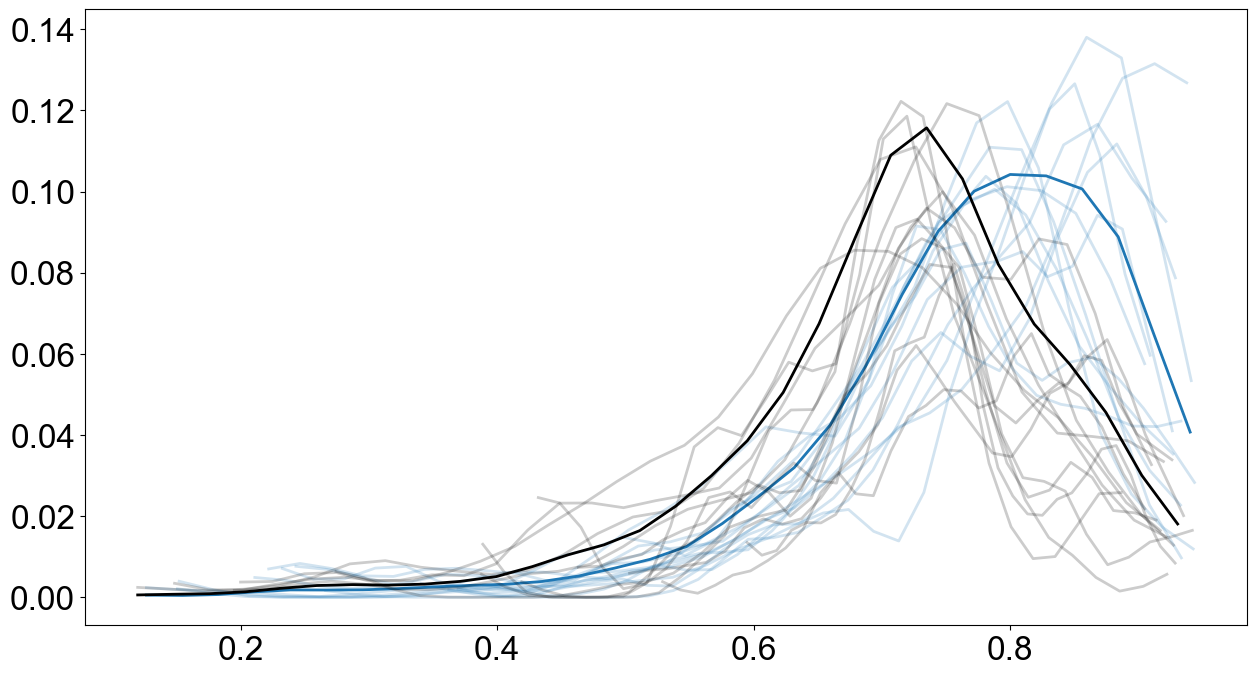

In [711]:
data = pd.concat([joint])
data = data[data.turn_to_obstacle == 'towards']
fig,ax = plt.subplots(1,1,figsize=(15,8),sharey =True)
light = data[data.task =='oa']
light_dist = (light.linearity.to_numpy())
light_dist = light_dist[np.where((light_dist>=0))]
light_counts, light_bins = np.histogram(light_dist, bins=30)
ax.plot(light_bins[:-1], smooth(light_counts/sum(light_counts)), 'b-', linewidth=2, label='Line',color = 'tab:blue')
#ax[0].fill_between(bins[:-1], counts, alpha=0.5, label='Fill')

for ani,ani_df in light.groupby(['animal']):
    ani_light_dists = (ani_df.linearity.to_numpy())
    ani_light_dists = ani_light_dists[np.where((ani_light_dists>=0))]
    counts, bins = np.histogram(ani_light_dists, bins=30)
    ax.plot(bins[:-1], smooth(counts/sum(counts)), 'b-', linewidth=2, label='Line', alpha=0.2,color = 'tab:blue')
    #ax[0].fill_between(bins[:-1], counts, alpha=0.2, label='Fill')

dark = data[data.task =='oadark']
dark_dist = (dark.linearity.to_numpy())
dark_dist = dark_dist[np.where((dark_dist>=0))]
counts, bins = np.histogram(dark_dist, bins=30)
ax.plot(bins[:-1], smooth(counts/sum(counts)), 'b-', linewidth=2, label='Line',color = 'black')
#ax[0].fill_between(bins[:-1], counts, alpha=0.5, label='Fill')

for ani,ani_df in dark.groupby(['animal']):
    ani_dark_dists = (ani_df.linearity.to_numpy())
    ani_dark_dists = ani_dark_dists[np.where((ani_dark_dists>=0))]
    counts, bins = np.histogram(ani_dark_dists, bins=30)
    ax.plot(bins[:-1], smooth(counts/sum(counts)), 'b-', linewidth=2, label='Line', alpha=0.2,color = 'black')

(0.4, 1.2)

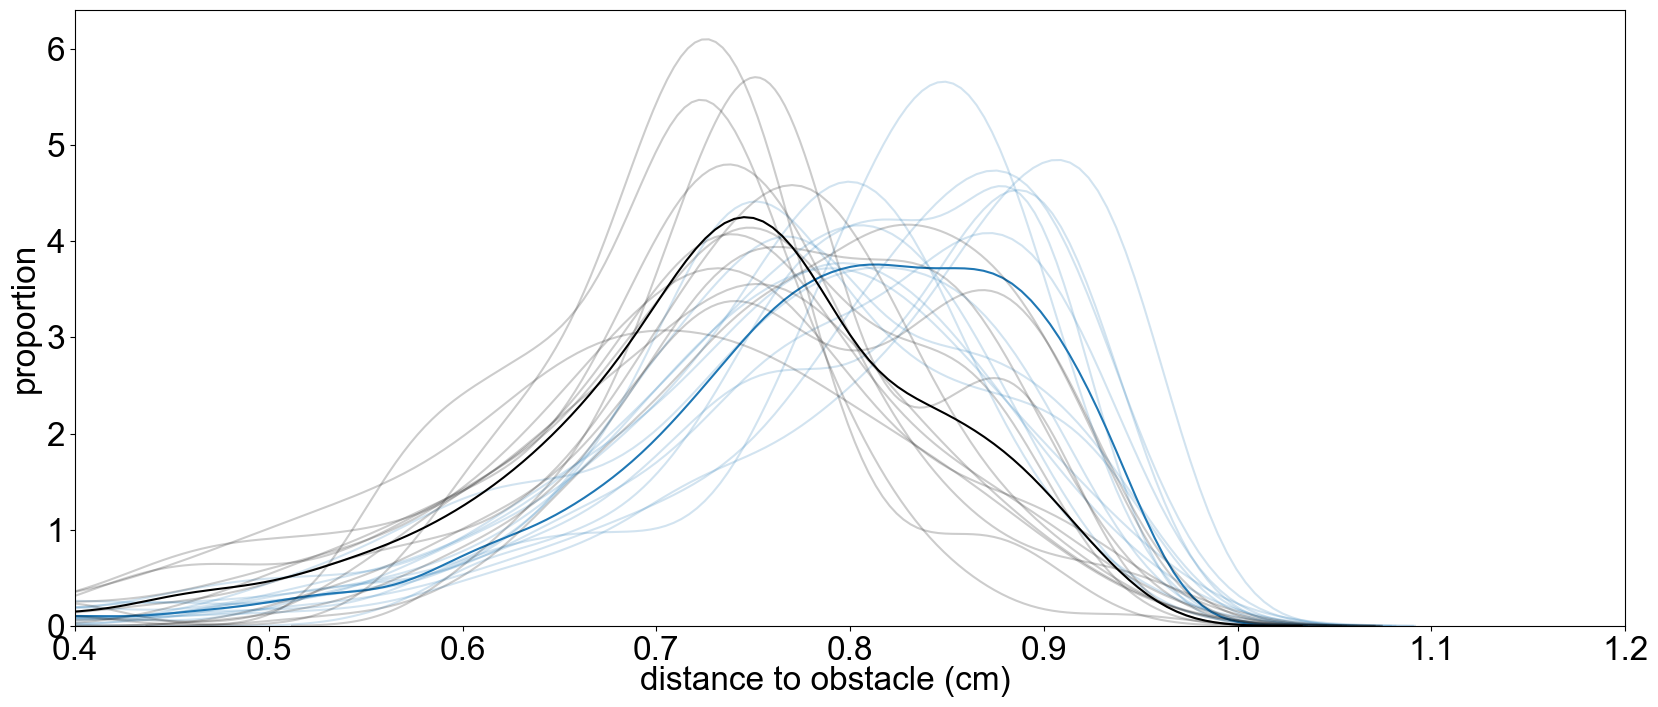

In [689]:
data = pd.concat([joint])
data = data[data.turn_to_obstacle == 'towards']
fig,ax = plt.subplots(1,1,figsize=(20,8),sharey =True)
light = data[data.task =='oa']
light_dist = (light.linearity.to_numpy())
light_dist = light_dist[np.where((light_dist>=0))]
counts, bins = np.histogram(light_dist, bins=30)
 
sns.kdeplot(ax = ax,data = light_dist,color = 'tab:blue')

for ani,ani_df in light.groupby(['animal']):
    ani_light_dists = (ani_df.linearity.to_numpy())
    ani_light_dists = ani_light_dists[np.where((ani_light_dists>=0))]
    sns.kdeplot(ax = ax,data = ani_light_dists,color = 'tab:blue', alpha = .2 )

dark = data[data.task =='oadark']
dark_dist = (dark.linearity.to_numpy())
dark_dist = dark_dist[np.where((dark_dist>=0))]

sns.kdeplot(ax = ax,data = dark_dist,color = 'black')

for ani,ani_df in dark.groupby(['animal']):
    ani_dark_dists = (ani_df.linearity.to_numpy())
    ani_dark_dists = ani_dark_dists[np.where((ani_dark_dists>=0))]
    sns.kdeplot(ax = ax,data = ani_dark_dists,color = 'black', alpha = .2 )


ax.set_ylabel('proportion')
fig.text(0.5, 0.03, 'distance to obstacle (cm)', ha='center')
ax.set_xlim(.4,1.2)



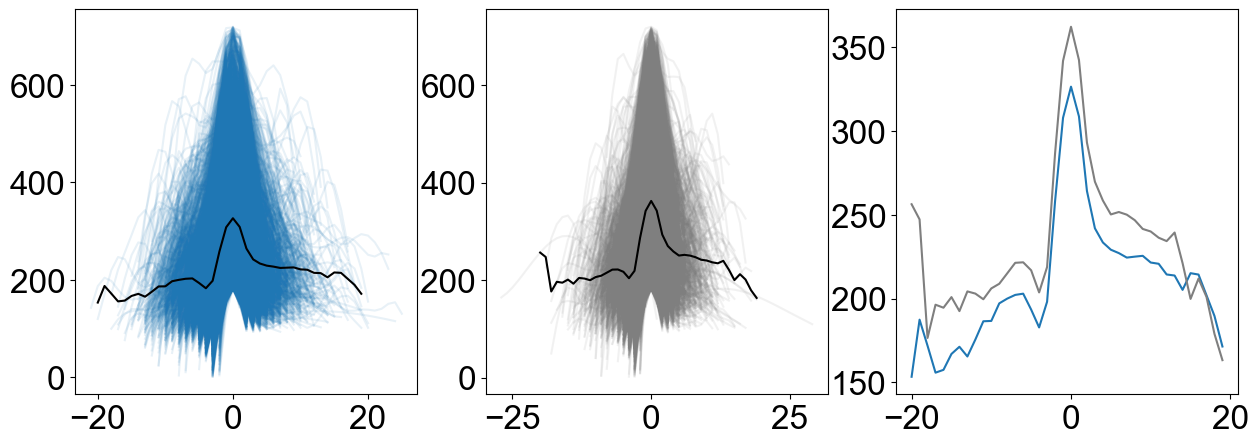

In [209]:
fig,ax = plt.subplots(1,3,figsize = (15,5))
head_turns =  []
resample_turns = []
fake_time_arr = []
xnew = np.arange(-20, 20, 1)

light = joint[(joint.task=='oa')]
for ind,row in light.iterrows():
    peaks, prop = find_peaks(np.abs(row.head_angle_velocity[:int(row.obstacle_ind)]), width=1,height=(3,12),prominence=1)
    inds = np.vstack([prop['left_ips'].astype(int),prop['right_ips'].astype(int)]).T
    for i,v in enumerate(inds):
        turn = np.abs(row.head_angle_velocity[:int(row.obstacle_ind)])[inds[i][0]:inds[i][1]+1]
        if len(turn)<= 5:
                continue
        else:
            fake_time = create_monotonic_array(len(turn),np.argwhere(turn == prop['peak_heights'][i]))
            fake_time_arr.append(fake_time.tolist()[0])
            head_turns.append(turn)
head_turns = np.asarray(head_turns)
fake_time_arr = np.asarray(fake_time_arr)

for idx,turn in enumerate(head_turns):
    if len(turn)<= 5:
        continue
    else: 
        ax[0].plot(fake_time_arr[idx],turn*60,c = 'tab:blue',alpha = .1)

        interpolater = interp1d(fake_time_arr[idx],turn,bounds_error=False)
        ynew = interpolater(xnew)
        trace =ynew
        #trace = pd.Series(trace).interpolate(limit_direction ='backward')
        #trace = pd.Series(trace).interpolate(limit_direction ='forward')
            
        #trace = trace.to_numpy()
        resample_turns.append(trace)
resample_turns = np.asarray(resample_turns)


ax[0].plot(xnew,np.nanmean(resample_turns,axis=0)*60,c = 'black')
ax[2].plot(xnew,np.nanmean(resample_turns,axis=0)*60,c = 'tab:blue')

dark = joint[(joint.task=='oadark')]
head_turns =  []
resample_turns = []
fake_time_arr = []
for ind,row in dark.iterrows():
    peaks, prop = find_peaks(np.abs(row.head_angle_velocity[:int(row.obstacle_ind)]), width=1,height=(3,12),prominence=1)
    inds = np.vstack([prop['left_ips'].astype(int),prop['right_ips'].astype(int)]).T
    for i,v in enumerate(inds):
        turn = np.abs(row.head_angle_velocity[:int(row.obstacle_ind)])[inds[i][0]:inds[i][1]+1]
        if len(turn)<= 5:
                continue
        else:
            fake_time = create_monotonic_array(len(turn),np.argwhere(turn == prop['peak_heights'][i]))
            fake_time_arr.append(fake_time.tolist()[0])
            head_turns.append(turn)
head_turns = np.asarray(head_turns)
fake_time_arr = np.asarray(fake_time_arr)

for idx,turn in enumerate(head_turns):
    if len(turn)<= 5:
        continue
    else: 
        ax[1].plot(fake_time_arr[idx],turn*60,c = 'tab:grey',alpha = .1)

        interpolater = interp1d(fake_time_arr[idx],turn,bounds_error=False)
        ynew = interpolater(xnew)
        trace =ynew
        #trace = pd.Series(trace).interpolate(limit_direction ='backward')
        #trace = pd.Series(trace).interpolate(limit_direction ='forward')
            
        #trace = trace.to_numpy()
        resample_turns.append(trace)
resample_turns = np.asarray(resample_turns)


ax[1].plot(xnew,np.nanmean(resample_turns,axis=0)*60,c = 'black')

ax[2].plot(xnew,np.nanmean(resample_turns,axis=0)*60,c = 'tab:grey')


In [672]:
row[1].head_corner_angle_velocity[thresh]

-0.32986913861901224

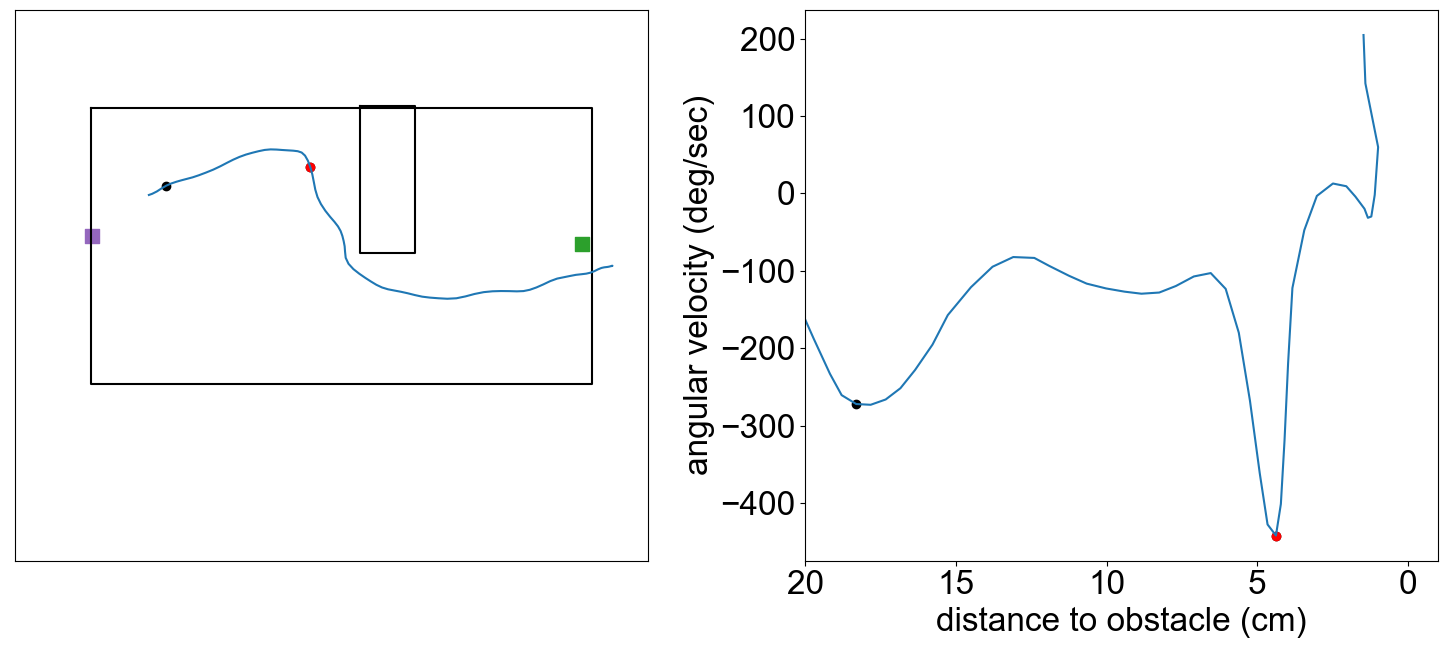

In [661]:
data = long[(long.obstacle_cluster == 1)&(long.task == 'oa')&(long.head_corner_angle_velocity_at_head_turn <= -5)]
#sample = data.sample(1)
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42  
for ind,row in sample.iterrows():
    fig,ax = plt.subplots( 1,2,figsize=(15,7),layout = 'tight')
    
    #ax[1].set_xlim(20,0)
    


    ax[0].set_xticks([])
    ax[0].set_yticks([])
    ax[1].set_xticks([0,5,10,15,20])
    ax[1].set_xlim(-1,20)
    ax[1].invert_xaxis()
    ax[1].set_ylabel('angular velocity (deg/sec)')
    ax[1].set_xlabel('distance to obstacle (cm)')
    #ax[1].invert_yaxis()
    plot_arena(data,ax[0])
    plot_orginal_obstacle(data,ax[0],int(row.obstacle_cluster))


    trial_df = data.loc[[ind]]
    

    for ind,row in trial_df.iterrows():
        
        #ax[1].set_title('head_corner_angle_velocity_at_head_turn head '+ str(row.head_corner_angle_velocity_at_head_turn) + ' '+row.task )

        #ax[1].set_ylim(-12,2)
        
        ob_ind = int(row.obstacle_ind)
        thresh = int(row.distance_at_head_turn_2_index)
        peaks = row.distance_at_head_turn_2_indexs.tolist()
        ax[0].plot(smooth(row.ts_nose_x_cm),smooth(row.ts_nose_y_cm),color = 'tab:blue')
        ax[0].scatter(smooth(row.ts_nose_x_cm)[peaks],smooth(row.ts_nose_y_cm)[peaks],color = 'black')
        ax[0].scatter(smooth(row.ts_nose_x_cm)[thresh],smooth(row.ts_nose_y_cm)[thresh],color = 'red')
        ax[1].plot(row.ts_distance_from_edge[:ob_ind],smooth(row.head_angle_velocity[:ob_ind])*60,color = 'tab:blue')
        ax[1].scatter(row.ts_distance_from_edge[:ob_ind][peaks],smooth(row.head_angle_velocity)[peaks]*60,color = 'black')
        ax[1].scatter(row.ts_distance_from_edge[:ob_ind][thresh],smooth(row.head_angle_velocity)[thresh]*60,color = 'red')

        #ax[1].scatter(thresh,smooth(row.head_angle_velocity)[thresh]*60,color = 'black')

        #ax[0].plot((smooth(row.ts_nose_x_cm)[::3],smooth(row.ts_spine_x_cm)[::3]),(smooth(row.ts_nose_y_cm)[::3],smooth(row.ts_spine_y_cm)[::3]),color = 'tab:orange')
        #ax[0].plot((smooth(row.ts_spine_x_cm)[::3],smooth(row.ts_tailbase_x_cm)[::3]),(smooth(row.ts_spine_y_cm)[::3],smooth(row.ts_tailbase_y_cm)[::3]),color = 'tab:green')
        #fig.savefig(r'd:\obstacle_avoidance\figures\SFN\vis_nav/head_movment_light_trace.pdf',dpi = 300)

meta NOT subset; don't know how to subset; dropped


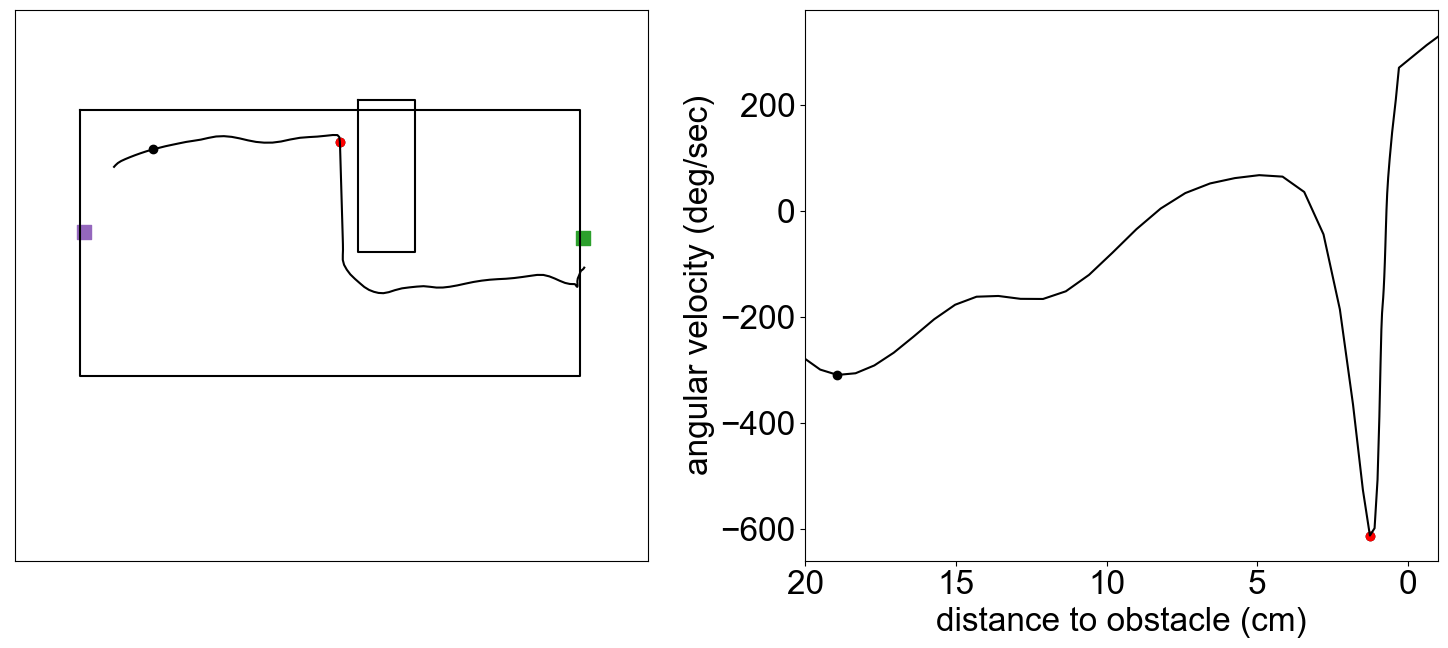

In [604]:
data = long[(long.obstacle_cluster == 1)&(long.task == 'oadark')&(long.head_corner_angle_velocity_at_head_turn <= -5)]
#sample_dark = data.sample(1)
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42  
for ind,row in sample_dark.iterrows():
    fig,ax = plt.subplots( 1,2,figsize=(15,7),layout = 'tight')
    
    #ax[1].set_xlim(20,0)
    


    ax[0].set_xticks([])
    ax[0].set_yticks([])
    ax[1].set_xticks([0,5,10,15,20])
    ax[1].set_xlim(-1,20)
    ax[1].invert_xaxis()
    ax[1].set_ylabel('angular velocity (deg/sec)')
    ax[1].set_xlabel('distance to obstacle (cm)')
    plot_arena(data,ax[0])
    plot_orginal_obstacle(data,ax[0],int(row.obstacle_cluster))


    trial_df = data.loc[[ind]]
    

    for ind,row in trial_df.iterrows():
        
        #ax[1].set_title('head_corner_angle_velocity_at_head_turn head '+ str(row.head_corner_angle_velocity_at_head_turn) + ' '+row.task )

        #ax[1].set_ylim(-12,2)
        
        ob_ind = int(row.obstacle_ind)
        thresh = int(row.distance_at_head_turn_2_index)
        peaks = row.distance_at_head_turn_2_indexs.tolist()
        ax[0].plot(smooth(row.ts_nose_x_cm),smooth(row.ts_nose_y_cm),color = 'black')
        ax[0].scatter(smooth(row.ts_nose_x_cm)[peaks],smooth(row.ts_nose_y_cm)[peaks],color = 'black')
        ax[0].scatter(smooth(row.ts_nose_x_cm)[thresh],smooth(row.ts_nose_y_cm)[thresh],color = 'red')
        ax[1].plot(row.ts_distance_from_edge[:ob_ind],smooth(row.head_angle_velocity[:ob_ind])*60,color = 'black')
        ax[1].scatter(row.ts_distance_from_edge[:ob_ind][peaks],smooth(row.head_angle_velocity)[peaks]*60,color = 'black')
        ax[1].scatter(row.ts_distance_from_edge[:ob_ind][thresh],smooth(row.head_angle_velocity)[thresh]*60,color = 'red')
        fig.savefig(r'd:\obstacle_avoidance\figures\SFN\vis_nav/head_movment_dark_trace.pdf',dpi = 300)

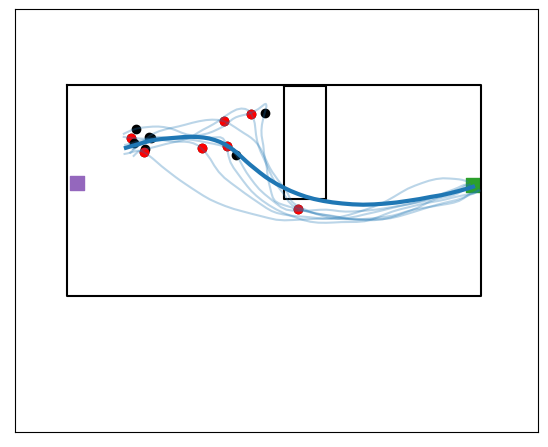

In [618]:
data = long[long.task == 'oa']
data = data[(data.distance_at_head_turn >= 0) ]
data = data[data.turn_to_obstacle == 'towards']
data = data[data['animal'].isin(['G8CKRT', 'G8CKLT', 'G8CKTT', 'G8CKRN', 'G8CKLN'])]
data = data[(data.obstacle_cluster == 1)&(data.odd == 'left')]
fig,ax = plt.subplots(layout = 'tight',figsize=(6,5))


ax.set_xticks([])
ax.set_yticks([])
mean_x = get_mean_of_df(data,'ts_nose_x_cm',50)
mean_y=get_mean_of_df(data,'ts_nose_y_cm',50)
trace_ax = data[(data.obstacle_cluster == 1)&(data.odd == 'left')].sample(7)     
plot_arena(trace_ax,ax,)
ob_x,ob_y  = plot_orginal_obstacle(trace_ax,ax,1)
for ind,row in trace_ax.iterrows():
    x = gaussian_filter(row.ts_nose_x_cm.astype(float),3)
    y = gaussian_filter(row.ts_nose_y_cm.astype(float),3)
    #ax.plot(x,y,c ='red', alpha =.5 )
    turn_index = int(row.distance_at_head_turn_2_index)
    peaks = row.distance_at_head_turn_2_indexs.tolist()
    cor_x,cor_y = correct_trace(row,ob_x,ob_y)
    ax.plot(cor_x,cor_y,c ='tab:blue', alpha =.3 )
    ax.scatter(cor_x[:int(row.obstacle_ind)][peaks],cor_y[:int(row.obstacle_ind)][peaks],c = 'black')
    ax.scatter(cor_x[:int(row.obstacle_ind)][turn_index],cor_y[:int(row.obstacle_ind)][turn_index],c = 'red')
ax.plot(mean_x,mean_y,c = 'tab:blue',linewidth=3.0)

Text(0, 0.5, 'proportion')

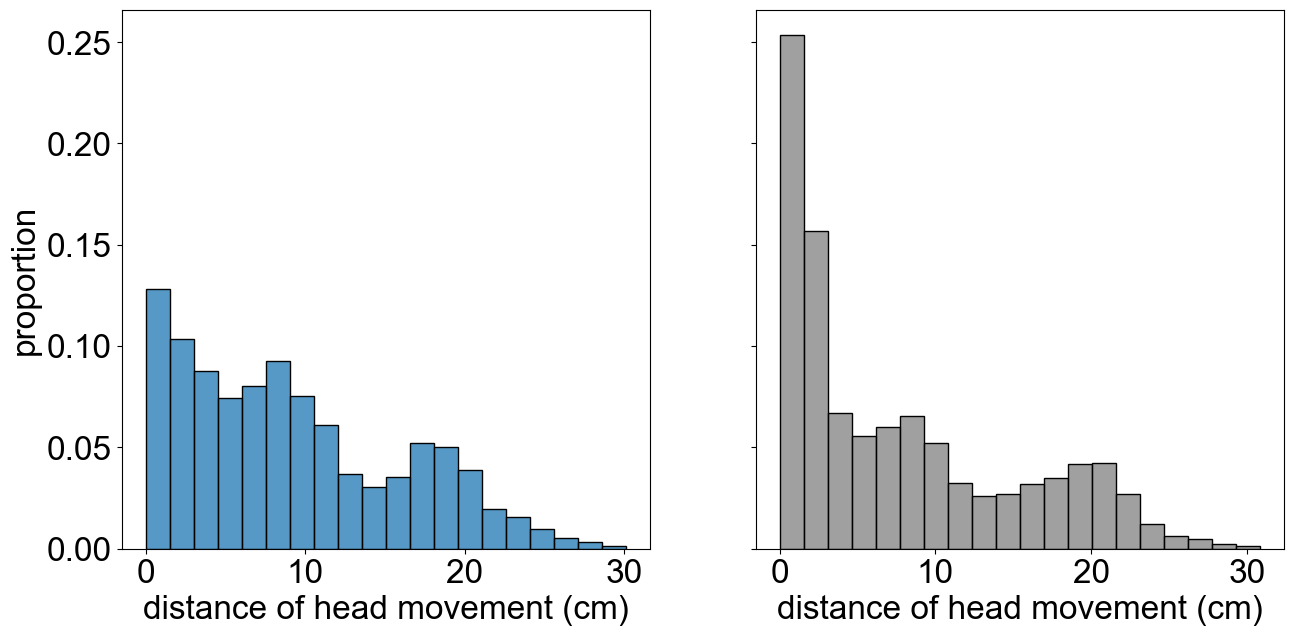

In [621]:
fig,ax = plt.subplots(1,2,sharey=True,figsize=(15,7))
head_turn_distances =  []
light = joint[(joint.task=='oa') ]
light = light[light.turn_to_obstacle=='towards']

for ind,row in light.iterrows():
    peaks, prop = find_peaks(np.abs(row.head_angle_velocity[:int(row.obstacle_ind)]), width=1,height=(2,12),prominence=1)
    inds = peaks
    for i,v in enumerate(inds):
        distance = row.ts_distance_from_edge[:int(row.obstacle_ind)][v]
        if distance >= 0: 
            head_turn_distances.append(distance)
        else:
            continue
#ax.hist(head_turn_distances,bins=20)
sns.histplot(ax= ax[0],data = head_turn_distances,bins=20,stat='proportion')

head_turn_distances =  []
dark = joint[(joint.task=='oadark') ]
dark = dark[dark.turn_to_obstacle=='towards']
for ind,row in dark.iterrows():
    peaks, prop = find_peaks(np.abs(row.head_angle_velocity[:int(row.obstacle_ind)]), width=1,height=(2,12),prominence=1)
    inds = peaks
    for i,v in enumerate(inds):
        distance = row.ts_distance_from_edge[:int(row.obstacle_ind)][v]
        if distance >= 0: 
            head_turn_distances.append(distance)
        else:
            continue
sns.histplot(ax= ax[1],data = head_turn_distances,bins=20,stat='proportion',color = 'grey')
ax[0].set_xlabel('distance of head movement (cm)')
ax[1].set_xlabel('distance of head movement (cm)')
ax[0].set_ylabel('proportion')

Text(0.5, 0, 'number of headturns ')

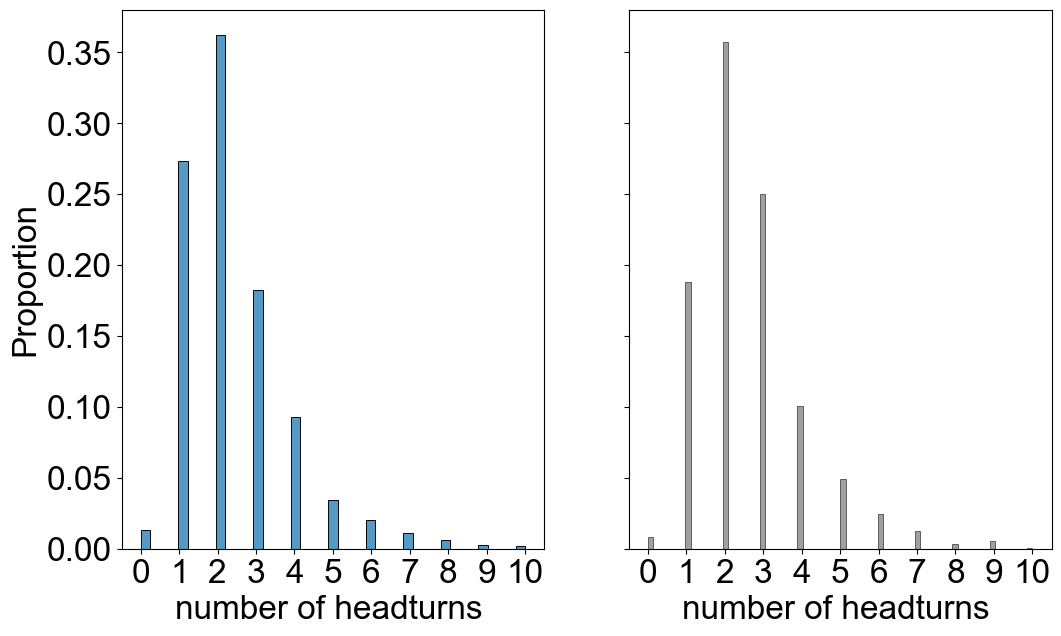

In [565]:
fig,ax = plt.subplots(1,2,sharey=True,figsize=(12,7))
light = joint[(joint.task=='oa') ]
light = light[light.turn_to_obstacle=='towards']
dark = joint[(joint.task=='oadark') ]
dark = dark[dark.turn_to_obstacle=='towards']
sns.histplot (ax =ax[0], data = light[light.num_turn <= 10]  ,x = 'num_turn',stat='proportion') 
sns.histplot (ax =ax[1], data = dark[dark.num_turn <= 10]   ,x = 'num_turn',stat='proportion',color ='grey') 
ax[0].set_xticks([0,1,2,3,4,5,6,7,8,9,10])
ax[1].set_xticks([0,1,2,3,4,5,6,7,8,9,10])
ax[0].set_xlabel('number of headturns ')
ax[1].set_xlabel('number of headturns ')

<ErrorbarContainer object of 3 artists>

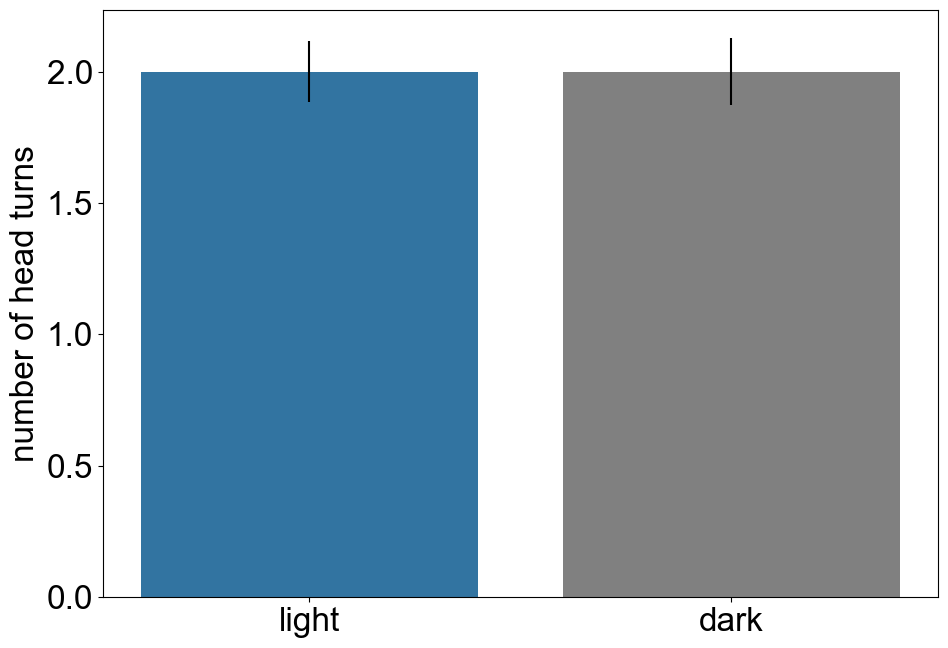

In [566]:
fig,ax = plt.subplots(figsize=(10,7),layout = 'tight')
data = pd.concat([joint])
data = data[data.turn_to_obstacle=='towards']

sns.barplot(ax = ax, data = data ,x='task' ,y = 'num_turn',hue = 'task',estimator = 'median',palette=['tab:blue','grey'],ci=None) 
#ax.set_yticks([0,5,10])
ax.set_ylabel('number of head turns')
ax.set_xlabel('')
ax.set_xticks([0,1],['light','dark'])


light = data[data.task == 'oa']
light_median = light.num_turn.median()
light_after= np.nanstd(light.groupby(['animal']).num_turn.median().to_numpy())/np.sqrt(len(light.groupby(['animal']).num_turn.median().to_numpy()))

dark = data[data.task == 'oadark']
dark_median = dark.num_turn.median()
dark_after= np.nanstd(dark.groupby(['animal']).num_turn.median().to_numpy())/np.sqrt(len(dark.groupby(['animal']).num_turn.median().to_numpy()))

ax.errorbar([0,1],[light_median,dark_median] , yerr=[light_after,dark_after], ls='none' ,color="black")
#fig.savefig(r'd:\obstacle_avoidance\figures\SFN\vis_nav/num_of_head_movements_light_dark_long.pdf',dpi = 300)


meta NOT subset; don't know how to subset; dropped


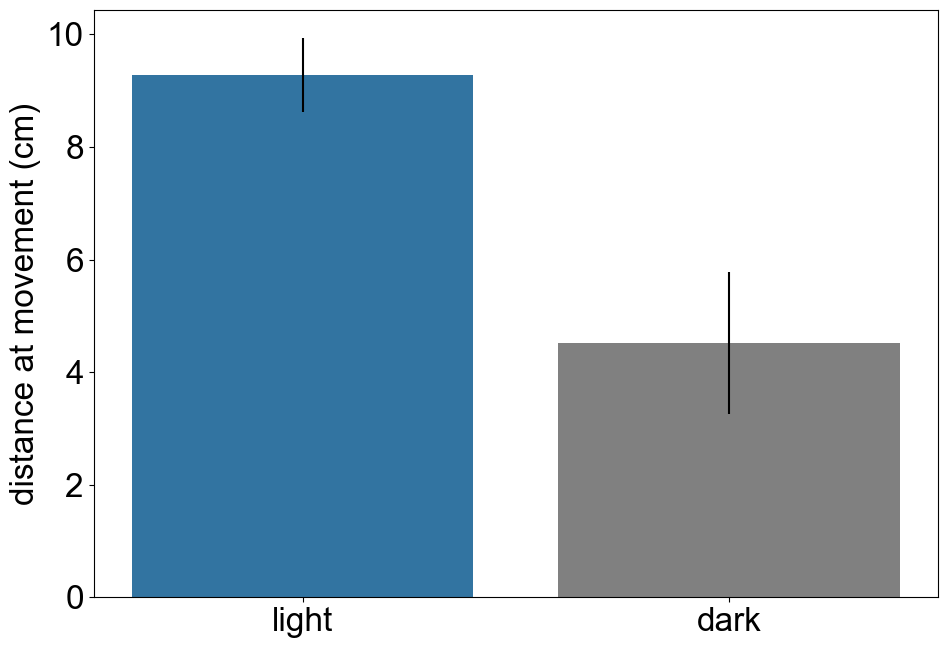

In [557]:
fig,ax = plt.subplots(figsize=(10,7),layout = 'tight')

data = long_nostart[long_nostart.turn_to_obstacle=='towards']

sns.barplot(ax = ax, data = data ,x='task' ,y = 'distance_at_head_turn_2',hue = 'task',estimator = 'median',palette=['tab:blue','grey'],ci=None) 
#ax.set_yticks([0,5,10])
ax.set_ylabel('distance at movement (cm)')
ax.set_xlabel('')
ax.set_xticks([0,1],['light','dark'])


light = data[data.task == 'oa']
light_mean = light.distance_at_head_turn_2.median()
light_after= np.nanstd(light.groupby(['animal']).distance_at_head_turn_2.median().to_numpy())/np.sqrt(len(light.groupby(['animal']).distance_at_head_turn_2.median().to_numpy()))

dark = data[data.task == 'oadark']
dark_mean = dark.distance_at_head_turn_2.median()
dark_after= np.nanstd(dark.groupby(['animal']).distance_at_head_turn_2.median().to_numpy())/np.sqrt(len(dark.groupby(['animal']).distance_at_head_turn_2.median().to_numpy()))

ax.errorbar([0,1],[light_mean,dark_mean] , yerr=[light_after,dark_after], ls='none' ,color="black")

fig.savefig(r'd:\obstacle_avoidance\figures\SFN\vis_nav/distance_at_head_turn_2_bar.pdf',dpi = 300)

meta NOT subset; don't know how to subset; dropped


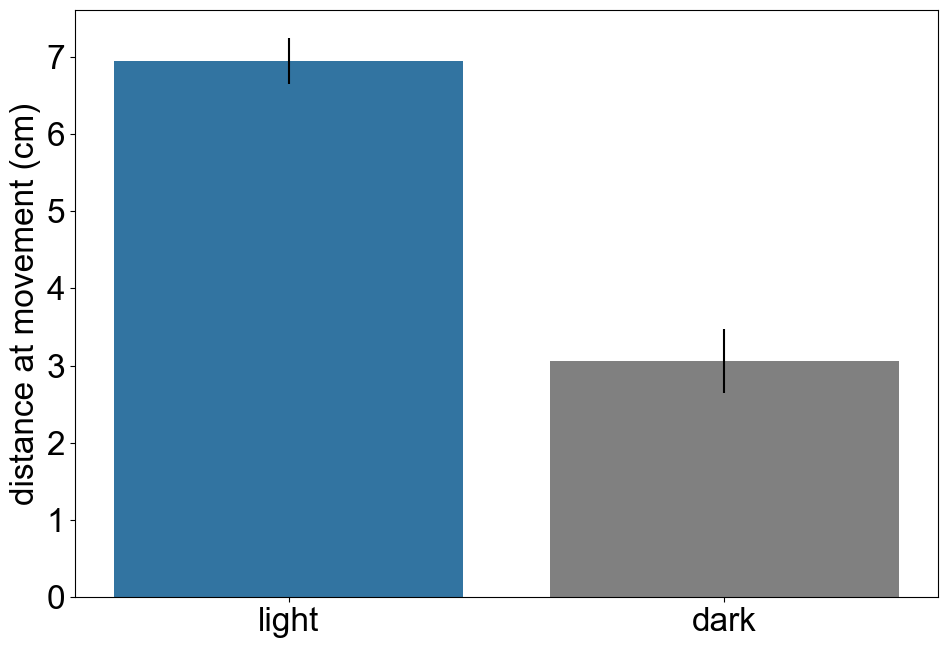

In [438]:
fig,ax = plt.subplots(figsize=(10,7),layout = 'tight')

data = joint[joint.turn_to_obstacle=='towards']

sns.barplot(ax = ax, data = data ,x='task' ,y = 'distance_at_head_turn_2',hue = 'task',estimator = 'median',palette=['tab:blue','grey'],ci=None) 
#ax.set_yticks([0,5,10])
ax.set_ylabel('distance at movement (cm)')
ax.set_xlabel('')
ax.set_xticks([0,1],['light','dark'])


light = data[data.task == 'oa']
light_mean = light.distance_at_head_turn_2.median()
light_after= np.nanstd(light.groupby(['animal']).distance_at_head_turn_2.median().to_numpy())/np.sqrt(len(light.groupby(['animal']).distance_at_head_turn_2.median().to_numpy()))

dark = data[data.task == 'oadark']
dark_mean = dark.distance_at_head_turn_2.median()
dark_after= np.nanstd(dark.groupby(['animal']).distance_at_head_turn_2.median().to_numpy())/np.sqrt(len(dark.groupby(['animal']).distance_at_head_turn_2.median().to_numpy()))

ax.errorbar([0,1],[light_mean,dark_mean] , yerr=[light_after,dark_after], ls='none' ,color="black")

fig.savefig(r'd:\obstacle_avoidance\figures\SFN\vis_nav/joint_distance_at_head_turn_2_bar.pdf',dpi = 300)

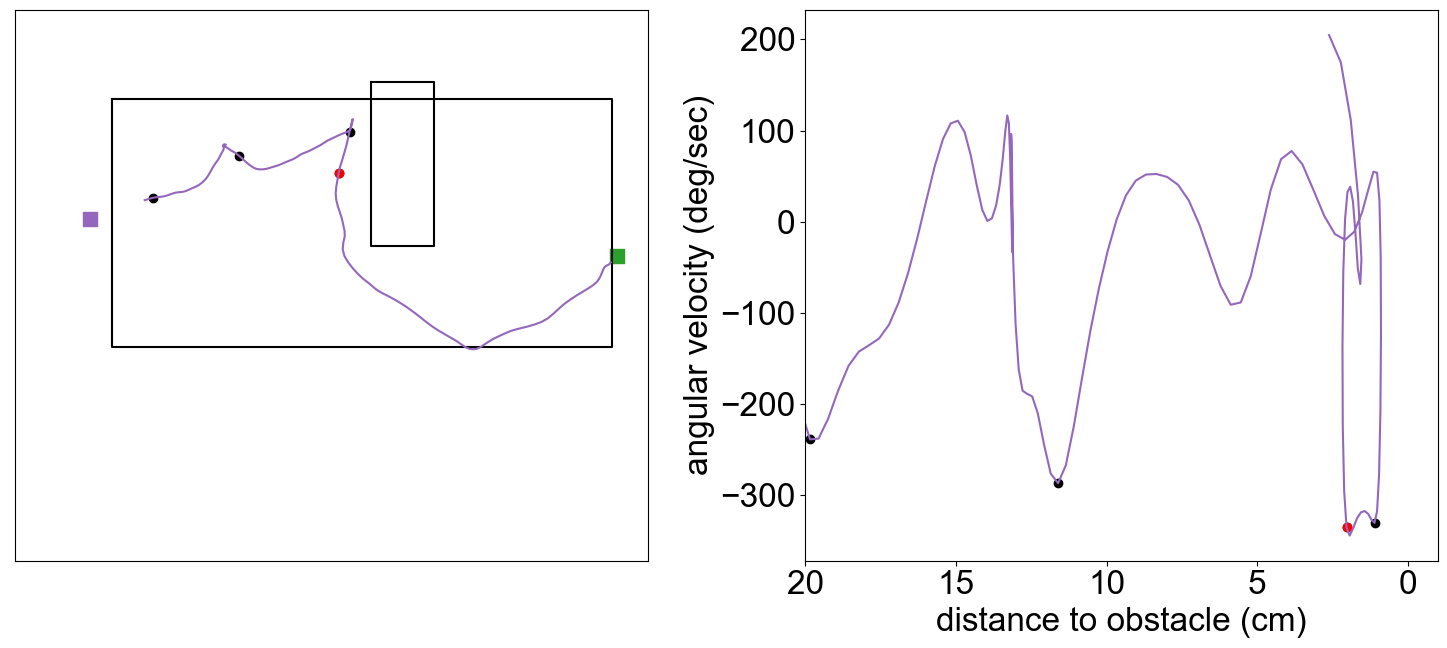

In [453]:
data = mon_long_nostart[(mon_long_nostart.obstacle_cluster == 1)&(mon_long_nostart.task == 'oamonre')&(mon_long_nostart.num_turn >= 3)]
mon_sample = data.sample(1)
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42  
for ind,row in mon_sample.iterrows():
    fig,ax = plt.subplots( 1,2,figsize=(15,7),layout = 'tight')
    
    #ax[1].set_xlim(20,0)
    


    ax[0].set_xticks([])
    ax[0].set_yticks([])
    ax[1].set_xticks([0,5,10,15,20])
    ax[1].set_xlim(-1,20)
    ax[1].invert_xaxis()
    ax[1].set_ylabel('angular velocity (deg/sec)')
    ax[1].set_xlabel('distance to obstacle (cm)')
    #ax[1].invert_yaxis()
    plot_arena(data,ax[0])
    plot_orginal_obstacle(data,ax[0],int(row.obstacle_cluster))


    trial_df = data.loc[[ind]]
    

    for ind,row in trial_df.iterrows():
        
        #ax[1].set_title('head_corner_angle_velocity_at_head_turn head '+ str(row.head_corner_angle_velocity_at_head_turn) + ' '+row.task )

        #ax[1].set_ylim(-12,2)
        
        ob_ind = int(row.obstacle_ind)
        thresh = int(row.distance_at_head_turn_2_index)
        peaks = row.distance_at_head_turn_2_indexs.tolist()
        ax[0].plot(smooth(row.ts_nose_x_cm),smooth(row.ts_nose_y_cm),color = 'tab:purple')
        ax[0].scatter(smooth(row.ts_nose_x_cm)[peaks],smooth(row.ts_nose_y_cm)[peaks],color = 'black')
        ax[0].scatter(smooth(row.ts_nose_x_cm)[thresh],smooth(row.ts_nose_y_cm)[thresh],color = 'red')
        ax[1].plot(row.ts_distance_from_edge[:ob_ind],smooth(row.head_angle_velocity[:ob_ind])*60,color = 'tab:purple')
        ax[1].scatter(row.ts_distance_from_edge[:ob_ind][peaks],smooth(row.head_angle_velocity)[peaks]*60,color = 'black')
        ax[1].scatter(row.ts_distance_from_edge[:ob_ind][thresh],smooth(row.head_angle_velocity)[thresh]*60,color = 'red')
        #ax[0].plot((row.ts_nose_x_cm[::3],row.ts_spine_x_cm[::3]),(row.ts_nose_y_cm[::3],row.ts_spine_y_cm[::3]),color = 'tab:orange')


In [ ]:
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
mon_df = mon_long_nostart[(mon_long_nostart.obstacle_cluster == 1)&(mon_long_nostart.task == 'oamonle')&(mon_long_nostart.turn_to_obstacle == 'towards')&(mon_long_nostart.time < 10)]

#light = light[light.linearity >= .8]

light_mon_df = light_mon_long_nostart[(light_mon_long_nostart.obstacle_cluster == 1)&(light_mon_long_nostart.task == 'oa')&(light_mon_long_nostart.turn_to_obstacle == 'towards')]

#mon_df = mon_df[mon_df.linearity >= .8]
fig,ax = plt.subplots(1,2,figsize=(13,5),)
ax[0].set_xticks([])
ax[0].set_yticks([])
ax[1].set_xticks([])
ax[1].set_yticks([])

plot_arena(light_mon_df,ax[0])
plot_arena(mon_df,ax[1])

ob_x,ob_y = plot_orginal_obstacle(light_mon_df,ax[0],5)
ob_x2,ob_y2 = plot_orginal_obstacle(mon_df,ax[1],5)

mon_df_nose_x = smooth(get_median_of_df(mon_df,'ts_nose_x_cm',50))
mon_df_nose_y = smooth(get_median_of_df(mon_df,'ts_nose_y_cm',50))

light_nose_x = smooth(get_median_of_df(light_mon_df,'ts_nose_x_cm',50))
light_nose_y = smooth(get_median_of_df(light_mon_df,'ts_nose_y_cm',50))

ax[1].plot(mon_df_nose_x,mon_df_nose_y,color = 'black',linewidth = 3)
ax[0].plot(light_nose_x,light_nose_y,linewidth = 3)

#light_sample = light_mon_df.sample(7)
for ind,row in light_sample.iterrows():
    x, y = correct_trace(row,ob_x,ob_y)
    ax[0].plot(x,y,alpha = .2 ,c = 'tab:blue')

#mon_df_sample = mon_df.sample(7)
for ind,row2 in mon_df_sample.iterrows():
    x1,y2 = correct_trace(row2,ob_x2,ob_y2)
    ax[1].plot(x1,y2,alpha = .2 ,c = 'black')

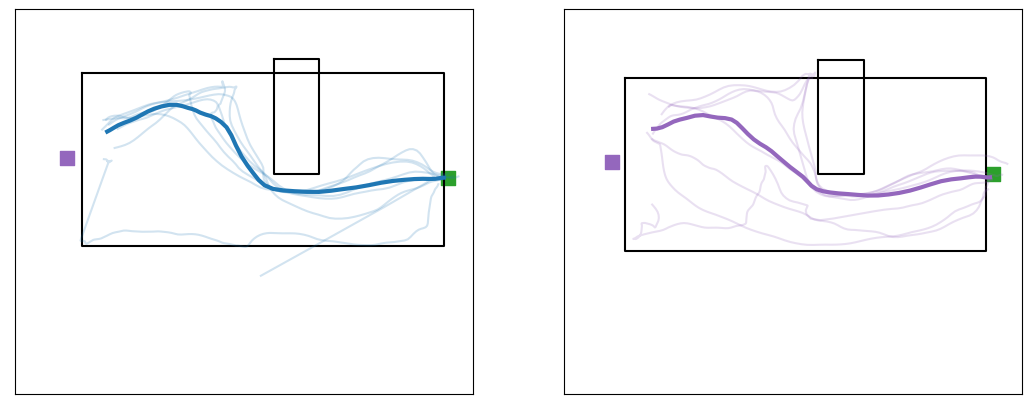

In [548]:
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
mon_df = mon_long_nostart[(mon_long_nostart.obstacle_cluster == 1)&(mon_long_nostart.task == 'oamonle')&(mon_long_nostart.turn_to_obstacle == 'towards')&(mon_long_nostart.time < 10)]

#light = light[light.linearity >= .8]

light_mon_df = light_mon_long_nostart[(light_mon_long_nostart.obstacle_cluster == 1)&(light_mon_long_nostart.task == 'oa')&(light_mon_long_nostart.turn_to_obstacle == 'towards')]

#mon_df = mon_df[mon_df.linearity >= .8]
fig,ax = plt.subplots(1,2,figsize=(13,5),)
ax[0].set_xticks([])
ax[0].set_yticks([])
ax[1].set_xticks([])
ax[1].set_yticks([])

plot_arena(light_mon_df,ax[0])
plot_arena(mon_df,ax[1])

ob_x,ob_y = plot_orginal_obstacle(light_mon_df,ax[0],5)
ob_x2,ob_y2 = plot_orginal_obstacle(mon_df,ax[1],5)

mon_df_nose_x = smooth(get_median_of_df(mon_df,'ts_nose_x_cm',50))
mon_df_nose_y = smooth(get_median_of_df(mon_df,'ts_nose_y_cm',50))

light_nose_x = smooth(get_median_of_df(light_mon_df,'ts_nose_x_cm',50))
light_nose_y = smooth(get_median_of_df(light_mon_df,'ts_nose_y_cm',50))

ax[1].plot(mon_df_nose_x,mon_df_nose_y,color = 'tab:purple',linewidth = 3)
ax[0].plot(light_nose_x,light_nose_y,linewidth = 3)

#light_sample = light_mon_df.sample(7)
for ind,row in light_sample.iterrows():
    x, y = correct_trace(row,ob_x,ob_y)
    ax[0].plot(x,y,alpha = .2 ,c = 'tab:blue')

#mon_df_sample = mon_df.sample(7)
for ind,row2 in mon_df_sample.iterrows():
    x1,y2 = correct_trace(row2,ob_x2,ob_y2)
    ax[1].plot(x1,y2,alpha = .2 ,c = 'tab:purple')

fig.savefig(r'd:\obstacle_avoidance\figures\SFN/vis_nav\light_mon_df_traces3_away.pdf',dpi = 300)

In [ ]:
mon_long_nostart

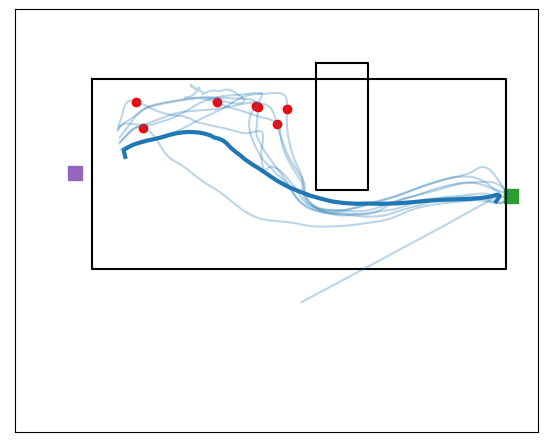

In [542]:
data = light_mon_long_nostart[light_mon_long_nostart.task_com == 'oa']
data = data[(data.distance_at_head_turn_2 >= 0) ]
data = data[data.turn_to_obstacle == 'towards']
#data = data[data['animal'].isin(['G8CKRT', 'G8CKLT', 'G8CKTT', 'G8CKRN', 'G8CKLN'])]
data = data[(data.obstacle_cluster == 1)&(data.odd == 'left')]
fig,ax = plt.subplots(layout = 'tight',figsize=(6,5))


ax.set_xticks([])
ax.set_yticks([])
mean_x = get_mean_of_df(data,'ts_nose_x_cm',50)
mean_y=get_mean_of_df(data,'ts_nose_y_cm',50)
#trace_ax = data[(data.obstacle_cluster == 1)&(data.odd == 'left')].sample(7)     
plot_arena(trace_ax,ax,)
ob_x,ob_y  = plot_orginal_obstacle(trace_ax,ax,1)
for ind,row in trace_ax.iterrows():
    x = gaussian_filter(row.ts_nose_x_cm.astype(float),3)
    y = gaussian_filter(row.ts_nose_y_cm.astype(float),3)
    #ax.plot(x,y,c ='red', alpha =.5 )
    turn_index = int(row.distance_at_head_turn_2_index)
    cor_x,cor_y = correct_trace(row,ob_x,ob_y)
    ax.plot(cor_x,cor_y,c ='tab:blue', alpha =.3 )
    ax.scatter(cor_x[:int(row.obstacle_ind)][turn_index],cor_y[:int(row.obstacle_ind)][turn_index],c = 'red')
ax.plot(mean_x,mean_y,c = 'tab:blue',linewidth=3.0)

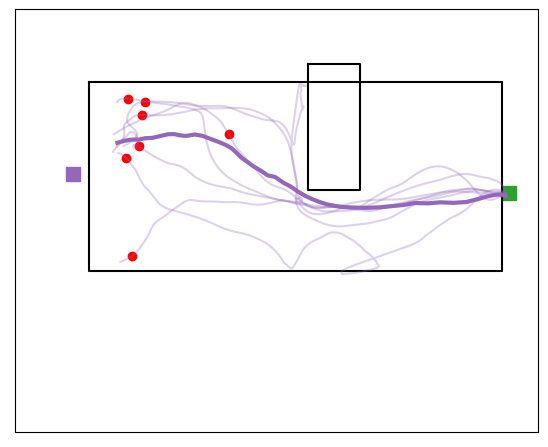

In [622]:
data = mon_long_nostart[mon_long_nostart.task_com == 'mon']
data = data[(data.distance_at_head_turn_2 >= 0) ]
data = data[data.turn_to_obstacle == 'towards']
#data = data[data['animal'].isin(['G8CKRT', 'G8CKLT', 'G8CKTT', 'G8CKRN', 'G8CKLN'])]
data = data[(data.obstacle_cluster == 1)&(data.odd == 'left')]
fig,ax = plt.subplots(layout = 'tight',figsize=(6,5))


ax.set_xticks([])
ax.set_yticks([])
mean_x = get_mean_of_df(data,'ts_nose_x_cm',50)
mean_y=get_mean_of_df(data,'ts_nose_y_cm',50)
#trace_ax_mon = data[(data.obstacle_cluster == 1)&(data.odd == 'left')].sample(7)     
plot_arena(trace_ax_mon,ax,)
ob_x,ob_y  = plot_orginal_obstacle(trace_ax_mon,ax,1)
for ind,row in trace_ax_mon.iterrows():
    x = gaussian_filter(row.ts_nose_x_cm.astype(float),3)
    y = gaussian_filter(row.ts_nose_y_cm.astype(float),3)
    #ax.plot(x,y,c ='red', alpha =.5 )
    turn_index = int(row.distance_at_head_turn_2_index)
    cor_x,cor_y = correct_trace(row,ob_x,ob_y)
    ax.plot(cor_x,cor_y,c ='tab:purple', alpha =.3 )
    ax.scatter(cor_x[:int(row.obstacle_ind)][turn_index],cor_y[:int(row.obstacle_ind)][turn_index],c = 'red')
ax.plot(mean_x,mean_y,c = 'tab:purple',linewidth=3.0)

In [466]:
dark.groupby(['animal']).num_turn.median()

Series([], Name: num_turn, dtype: float64)

In [464]:
light.groupby(['animal']).num_turn.median().to_numpy()

array([2., 2.])

In [463]:
np.sqrt(len(light.groupby(['animal']).num_turn.median().to_numpy()))

1.4142135623730951

In [469]:
light

,level_0,first_poke,second_poke,trial_timestamps,trial_vidframes,nose_x,nose_y,leftear_x,leftear_y,rightear_x,...,distance_at_head_turn_2,distance_at_head_turn_2_index,distance_at_head_turn_2_indexs,angle_at_head_turn_2,num_turn,right_num_turn,right_turns_distances,left_num_turn,left_turns_distances,task_com
51,NaN,48646.970752,48659.914982,"[48646.977241, 48646.994508, 48647.010688, 486...","[[11527, 11528, 11529, 11530, 11531, 11532, 11...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[646.1917114257812, 647.29833984375, 648.98278...","[235.03245544433594, 235.68272399902344, 237.3...","[640.0242309570312, 641.44677734375, 641.65808...",...,-21.934296,260.0,"[49, 174, 200, 217, 243, 260]",179.375528,6.0,4.0,"[5.087742232322867, -0.10253459186115066, 1.52...",2.0,"[1.2542172430725669, -12.4908676296768]",oa
78,NaN,47829.413107,47831.833945,"[47829.41774, 47829.43438, 47829.450892, 47829...","[[2596, 2597, 2598, 2599, 2600, 2601, 2602, 26...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[643.5426635742188, 645.4880981445312, 646.413...","[243.5281524658203, 243.15432739257812, 242.68...","[648.5927124023438, 650.214111328125, 651.0437...",...,4.498870,24.0,"[15, 24]",55.113841,2.0,2.0,"[10.178969623607657, 4.498870251275157]",0.0,[],oa
89,NaN,47865.469107,47868.234099,"[47865.479897, 47865.49728, 47865.51328, 47865...","[[4759, 4760, 4761, 4762, 4763, 4764, 4765, 47...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[642.0687255859375, 643.9666137695312, 644.632...","[245.3645782470703, 244.5995330810547, 244.385...","[648.5415649414062, 650.4345092773438, 650.475...",...,5.573982,37.0,"[5, 24, 37]",36.649419,3.0,3.0,"[20.760426229461977, 9.261443159990755, 5.5739...",0.0,[],oa
104,NaN,47915.219225,47918.701120,"[47915.230515, 47915.247731, 47915.263897, 479...","[[7743, 7744, 7745, 7746, 7747, 7748, 7749, 77...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[641.9148559570312, 643.0370483398438, 644.265...","[244.0486297607422, 243.00650024414062, 242.30...","[646.448486328125, 647.4270629882812, 648.4986...",...,23.335261,2.0,"[2, 41]",44.930730,2.0,1.0,[23.335261045944563],1.0,[10.77295295183333],oa
106,NaN,47922.588710,47925.320844,"[47922.599462, 47922.61728, 47922.633024, 4792...","[[8185, 8186, 8187, 8188, 8189, 8190, 8191, 81...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[643.7379760742188, 644.698486328125, 645.3103...","[241.52932739257812, 241.2022705078125, 241.45...","[648.2550659179688, 648.7424926757812, 649.260...",...,21.420608,8.0,"[2, 8]",23.802748,2.0,2.0,"[23.303763541272605, 21.420607659136433]",0.0,[],oa
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
680,NaN,47361.988403,47364.720601,"[47361.9968, 47362.013478, 47362.030489, 47362...","[6616, 6617, 6618, 6619, 6620, 6621, 6622, 662...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[95.24439239501953, 95.08486938476562, 93.7097...","[233.17922973632812, 233.63021850585938, 234.0...","[95.25648498535156, 93.28032684326172, 91.3796...",...,14.778439,20.0,"[6, 20]",24.616341,2.0,2.0,"[19.5420369307586, 14.778438697628374]",0.0,[],oa
701,NaN,47436.820454,47440.503065,"[47436.82272, 47436.839552, 47436.857177, 4743...","[11104, 11105, 11106, 11107, 11108, 11109, 111...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[98.111572265625, 96.95411682128906, 95.869888...","[232.82164001464844, 234.47528076171875, 235.2...","[96.01180267333984, 93.66996765136719, 91.7766...",...,19.320824,4.0,"[4, 29, 42]",36.928285,3.0,1.0,[19.32082366051445],2.0,"[12.954051957052942, 10.52082624524845]",oa
710,NaN,47468.128896,47471

In [473]:
dark_after

0.0

In [476]:
np.nanstd(light.groupby(['animal']).num_turn.median().to_numpy())

0.46153846153846156

In [477]:
np.sqrt(len(light.groupby(['animal']).num_turn.median().to_numpy()))

3.605551275463989

In [493]:
light_mean

2.0

In [480]:
light_mean

2.0

In [487]:
dark.groupby(['animal']).num_turn.median().to_numpy()

array([3., 3.])

In [494]:
light.groupby(['animal']).num_turn.median().to_numpy()

array([2., 2.])

In [497]:
data

,index,first_poke,second_poke,trial_timestamps,trial_vidframes,nose_x,nose_y,leftear_x,leftear_y,rightear_x,...,std_interp_ts_nose_y_cm,mad_interp_ts_nose_y_cm,animal_mean_interp_ts_nose_y_cm,animal_median_interp_ts_nose_y_cm,animal_std_interp_ts_nose_y_cm,animal_mad_interp_ts_nose_y_cm,date_mean_interp_ts_nose_y_cm,date_median_interp_ts_nose_y_cm,date_std_interp_ts_nose_y_cm,date_mad_interp_ts_nose_y_cm
51,59.0,48646.970752,48659.914982,"[48646.977241, 48646.994508, 48647.010688, 486...","[[11527, 11528, 11529, 11530, 11531, 11532, 11...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[646.1917114257812, 647.29833984375, 648.98278...","[235.03245544433594, 235.68272399902344, 237.3...","[640.0242309570312, 641.44677734375, 641.65808...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
78,15.0,47829.413107,47831.833945,"[47829.41774, 47829.43438, 47829.450892, 47829...","[[2596, 2597, 2598, 2599, 2600, 2601, 2602, 26...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[643.5426635742188, 645.4880981445312, 646.413...","[243.5281524658203, 243.15432739257812, 242.68...","[648.5927124023438, 650.214111328125, 651.0437...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
89,27.0,47865.469107,47868.234099,"[47865.479897, 47865.49728, 47865.51328, 47865...","[[4759, 4760, 4761, 4762, 4763, 4764, 4765, 47...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[642.0687255859375, 643.9666137695312, 644.632...","[245.3645782470703, 244.5995330810547, 244.385...","[648.5415649414062, 650.4345092773438, 650.475...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
104,43.0,47915.219225,47918.701120,"[47915.230515, 47915.247731, 47915.263897, 479...","[[7743, 7744, 7745, 7746, 7747, 7748, 7749, 77...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[641.9148559570312, 643.0370483398438, 644.265...","[244.0486297607422, 243.00650024414062, 242.30...","[646.448486328125, 647.4270629882812, 648.4986...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
106,45.0,47922.588710,47925.320844,"[47922.599462, 47922.61728, 47922.633024, 4792...","[[8185, 8186, 8187, 8188, 8189, 8190, 8191, 81...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[643.7379760742188, 644.698486328125, 645.3103...","[241.52932739257812, 241.2022705078125, 241.45...","[648.2550659179688, 648.7424926757812, 649.260...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
813,NaN,55038.203276,55042.209523,"[55038.210956, 55038.227148, 55038.243737, 550...","[17819, 17820, 17821, 17822, 17823, 17824, 178...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[92.54739379882812, 91.34406280517578, 89.9898...","[238.85906982421875, 239.54969787597656, 240.4...","[92.65906524658203, 91.19224548339844, 89.7385...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
825,NaN,55076.135526,55080.407897,"[55076.140569, 55076.156966, 55076.173785, 550...","[20094, 20095, 20096, 20097, 20098, 20099, 201...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[88.75123596191406, 88.19107818603516, 87.3225...","[243.80426025390625, 243.81190490722656, 244.3...","[95.22281646728516, 94.03811645507812, 92.3483...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
833,NaN,55099.877811,55103.417126,"[55099.881638, 55099.898496, 55099.915212, 550...","[21518, 21519, 21520, 21521, 21522, 21523, 215...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[89.07156372070312, 88.13114166259766, 87.1236...","[243.03115844726562, 243.0251922607422, 242.42...","[92.91146087646484, 92.02715301513672, 91.5012...",...,NaN,Na

In [500]:
data.distance_at_head_turn_2

0     -21.934296
1       4.498870
2       5.573982
3      23.335261
4      21.420608
         ...    
365    18.017817
366    14.441142
367    16.893544
368    19.261591
369    16.720961
Name: distance_at_head_turn_2, Length: 370, dtype: float64

<ErrorbarContainer object of 3 artists>

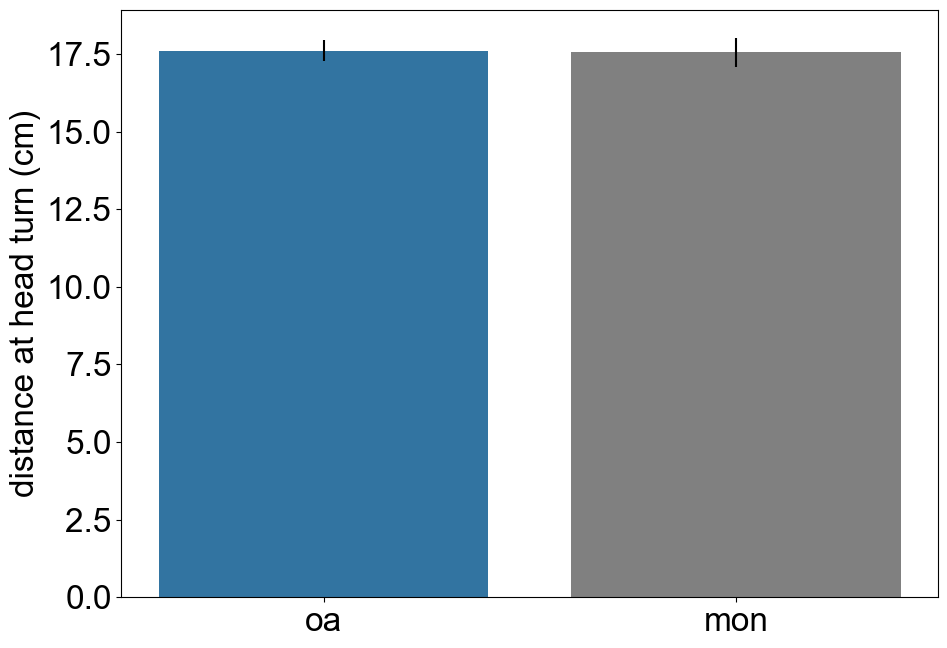

In [561]:
fig,ax = plt.subplots(figsize=(10,7),layout = 'tight')
data = pd.concat([light_mon_long_nostart,mon_long_nostart])
data = data[data.turn_to_obstacle=='towards']
data = data.drop(columns = ['level_0'])
data = data.reset_index()

sns.barplot(ax = ax, data = data ,x='task_com' ,y = 'distance_at_head_turn_2',hue = 'task_com',estimator = 'median',palette=['tab:blue','grey'],ci=None) 
#ax.set_yticks([0,5,10])
ax.set_ylabel('distance at head turn (cm)')
ax.set_xlabel('')
#ax.set_xticks([0,1],['light','dark'])


light = data[data.task == 'oa']
light_mean = light.distance_at_head_turn_2.median()
light_after= np.nanstd(light.groupby(['animal']).distance_at_head_turn_2.median().to_numpy())/np.sqrt(len(light.groupby(['animal']).distance_at_head_turn_2.median().to_numpy()))

dark = data[data.task_com == 'mon']
dark_mean = dark.distance_at_head_turn_2.median()
dark_after= np.nanstd(dark.groupby(['animal']).distance_at_head_turn_2.median().to_numpy())/np.sqrt(len(dark.groupby(['animal']).distance_at_head_turn_2.median().to_numpy()))

ax.errorbar([0,1],[light_mean,dark_mean] , yerr=[light_after,dark_after], ls='none' ,color="black")

<ErrorbarContainer object of 3 artists>

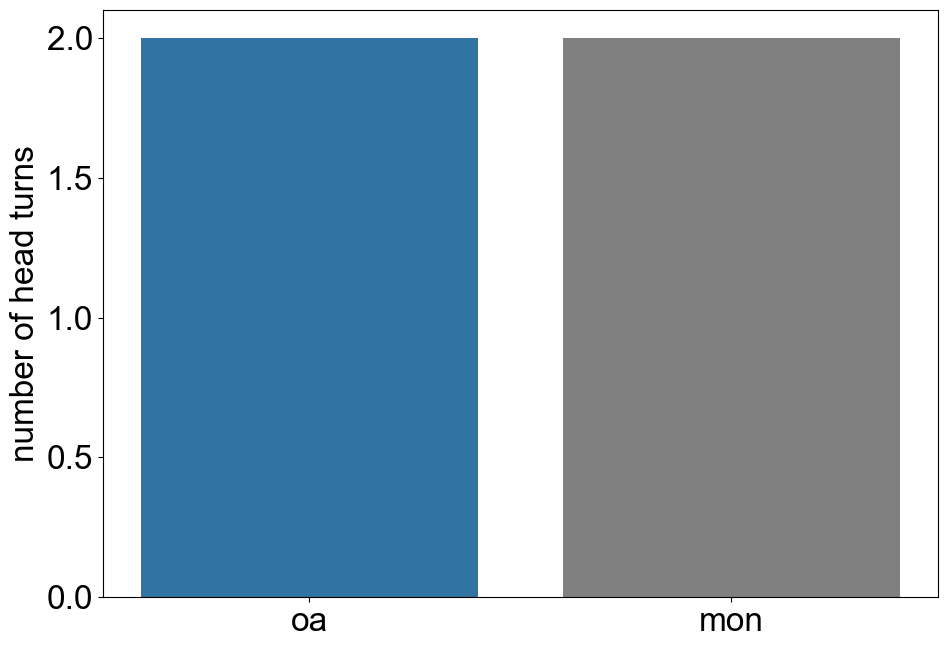

In [575]:
fig,ax = plt.subplots(figsize=(10,7),layout = 'tight')
data = pd.concat([light_mon_long_nostart,light_mon_short_nostart,mon_long_nostart,mon_short_nostart])
data = data[data.turn_to_obstacle=='towards']
data = data[data.num_turn<=10]
data = data[data.time<=10]

sns.barplot(ax = ax, data = data ,x='task_com' ,y = 'num_turn',hue = 'task_com',estimator = 'median',palette=['tab:blue','grey'],ci=None) 
#ax.set_yticks([0,5,10])
ax.set_ylabel('number of head turns')
ax.set_xlabel('')
#ax.set_xticks([0,1],['light','dark'])


light = data[data.task == 'oa']
light_mean = light.num_turn.median()
light_after= np.nanstd(light.groupby(['animal']).num_turn.median().to_numpy())/np.sqrt(len(light.groupby(['animal']).num_turn.median().to_numpy()))

dark = data[data.task_com == 'mon']
dark_mean = dark.num_turn.median()
dark_after= np.nanstd(dark.groupby(['animal']).num_turn.median().to_numpy())/np.sqrt(len(dark.groupby(['animal']).num_turn.median().to_numpy()))

ax.errorbar([0,1],[light_mean,dark_mean] , yerr=[light_after,dark_after], ls='none' ,color="black")

In [599]:
data

,level_0,index,first_poke,second_poke,trial_timestamps,trial_vidframes,nose_x,nose_y,leftear_x,leftear_y,...,std_interp_ts_nose_y_cm,mad_interp_ts_nose_y_cm,animal_mean_interp_ts_nose_y_cm,animal_median_interp_ts_nose_y_cm,animal_std_interp_ts_nose_y_cm,animal_mad_interp_ts_nose_y_cm,date_mean_interp_ts_nose_y_cm,date_median_interp_ts_nose_y_cm,date_std_interp_ts_nose_y_cm,date_mad_interp_ts_nose_y_cm
3,51,59.0,48646.970752,48659.914982,"[48646.977241, 48646.994508, 48647.010688, 486...","[[11527, 11528, 11529, 11530, 11531, 11532, 11...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[646.1917114257812, 647.29833984375, 648.98278...","[235.03245544433594, 235.68272399902344, 237.3...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,78,15.0,47829.413107,47831.833945,"[47829.41774, 47829.43438, 47829.450892, 47829...","[[2596, 2597, 2598, 2599, 2600, 2601, 2602, 26...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[643.5426635742188, 645.4880981445312, 646.413...","[243.5281524658203, 243.15432739257812, 242.68...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,89,27.0,47865.469107,47868.234099,"[47865.479897, 47865.49728, 47865.51328, 47865...","[[4759, 4760, 4761, 4762, 4763, 4764, 4765, 47...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[642.0687255859375, 643.9666137695312, 644.632...","[245.3645782470703, 244.5995330810547, 244.385...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,104,43.0,47915.219225,47918.701120,"[47915.230515, 47915.247731, 47915.263897, 479...","[[7743, 7744, 7745, 7746, 7747, 7748, 7749, 77...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[641.9148559570312, 643.0370483398438, 644.265...","[244.0486297607422, 243.00650024414062, 242.30...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,106,45.0,47922.588710,47925.320844,"[47922.599462, 47922.61728, 47922.633024, 4792...","[[8185, 8186, 8187, 8188, 8189, 8190, 8191, 81...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[643.7379760742188, 644.698486328125, 645.3103...","[241.52932739257812, 241.2022705078125, 241.45...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1204,832,NaN,55097.498368,55099.877811,"[55097.498419, 55097.51447, 55097.53111, 55097...","[[21375, 21376, 21377, 21378, 21379, 21380, 21...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[649.4237060546875, 650.5474243164062, 650.832...","[234.89065551757812, 237.0601348876953, 239.64...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1205,834,NaN,55103.417126,55106.104192,"[55103.433152, 55103.450035, 55103.466521, 551...","[[21731, 21732, 21733, 21734, 21735, 21736, 21...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[647.20068359375, 648.5572509765625, 649.28778...","[239.66661071777344, 241.1394805908203, 242.03...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1206,859,NaN,55225.689152,55227.622400,"[55225.692684, 55225.709171, 55225.725542, 552...","[[29064, 29065, 29066, 29067, 29068, 29069, 29...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[646.2739868164062, 647.8783569335938, 648.872...","[238.5966033935547, 239.61167907714844, 240.69...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1207,866,NaN,55250.041664,55252.642854,"[55250.050572, 55250.067187, 55250.084569, 552...","[[30525, 30526, 30527, 30528, 30529, 30530, 30...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[650.2250366210938, 650.468017578125, 650.3681...","[237.76907348632812, 239.40895080566406, 239.2...",...,NaN,N

<ErrorbarContainer object of 3 artists>

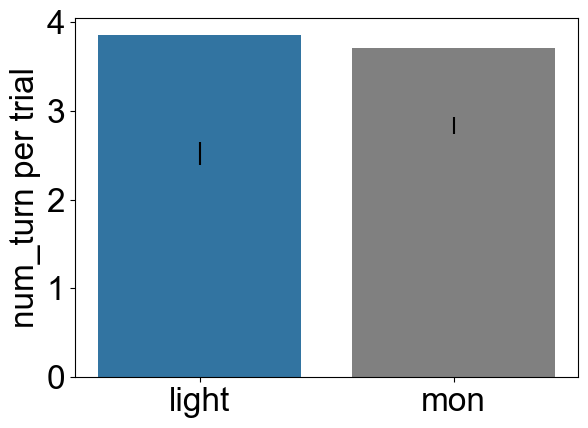

In [600]:
fig,ax = plt.subplots(layout = 'tight')
data = pd.concat([light_mon_long_nostart,light_mon_short_nostart,mon_long_nostart,mon_short_nostart])

data = data[data.turn_to_obstacle == 'towards']
light = data[data.task_com == 'oa']
light = light[light.time<=10]
dark = data[data.task_com == 'mon']
dark = dark[dark.time<=10]
#data =  pd.concat([light,dark]) 

sns.barplot(ax = ax, data = data ,x='task_com' ,y = 'num_turn',hue = 'task_com',estimator = 'mean',palette=['tab:blue','grey'],ci=None) 
#ax.set_yticks([0,5,10])
ax.set_ylabel('num_turn per trial')
ax.set_xlabel('')
ax.set_xticks([0,1],['light','mon'])


light = data[data.task_com == 'oa']
light = light[light.time<=10]
light_mean = light.num_turn.mean()
light_after= np.nanstd(light.groupby(['animal']).num_turn.mean().to_numpy())/np.sqrt(len(light.groupby(['animal']).num_turn.mean().to_numpy()))

dark = data[data.task_com == 'mon']
dark = dark[dark.time<=10]
dark_mean = dark.num_turn.mean()
dark_after= np.nanstd(dark.groupby(['animal']).num_turn.mean().to_numpy())/np.sqrt(len(dark.groupby(['animal']).num_turn.mean().to_numpy()))

ax.errorbar([0,1],[light_mean,dark_mean] , yerr=[light_after,dark_after], ls='none' ,color="black")

Text(0.5, 0, 'number of headturns ')

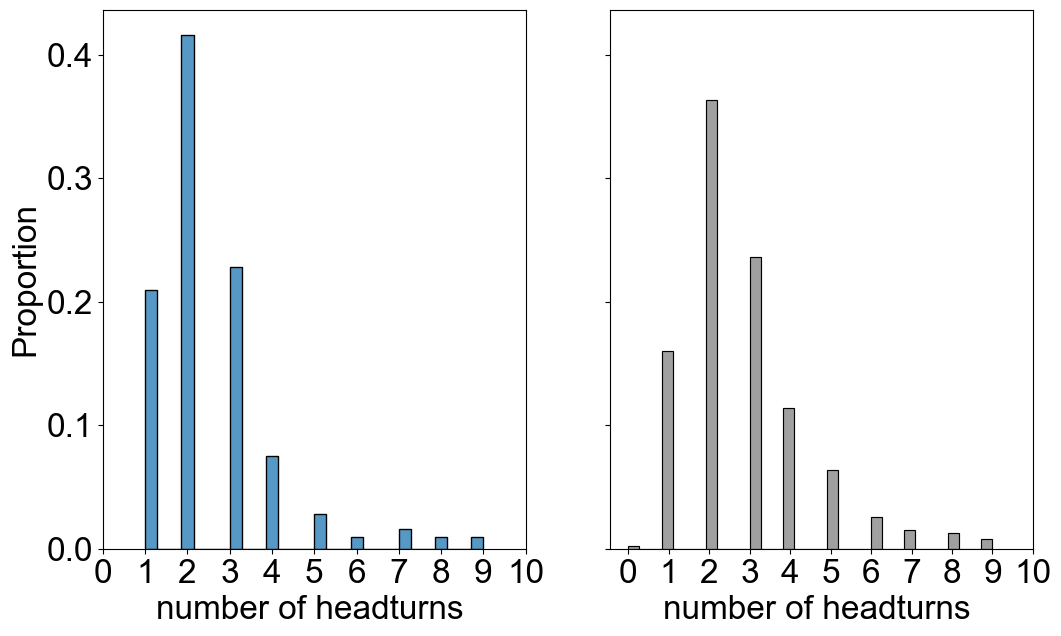

In [573]:
fig,ax = plt.subplots(1,2,sharey=True,figsize=(12,7))
data = pd.concat([light_mon_long_nostart,light_mon_short_nostart,mon_long_nostart,mon_short_nostart])
light = data[(data.task=='oa') ]
light = light[light.turn_to_obstacle=='towards']
dark = data[(data.task_com=='mon') ]
dark = dark[dark.turn_to_obstacle=='towards']
sns.histplot (ax =ax[0], data = light[light.num_turn <= 10]  ,x = 'num_turn',stat='proportion') 
sns.histplot (ax =ax[1], data = dark[dark.num_turn <= 10]   ,x = 'num_turn',stat='proportion',color ='grey') 
ax[0].set_xticks([0,1,2,3,4,5,6,7,8,9,10])
ax[1].set_xticks([0,1,2,3,4,5,6,7,8,9,10])
ax[0].set_xlabel('number of headturns ')
ax[1].set_xlabel('number of headturns ')

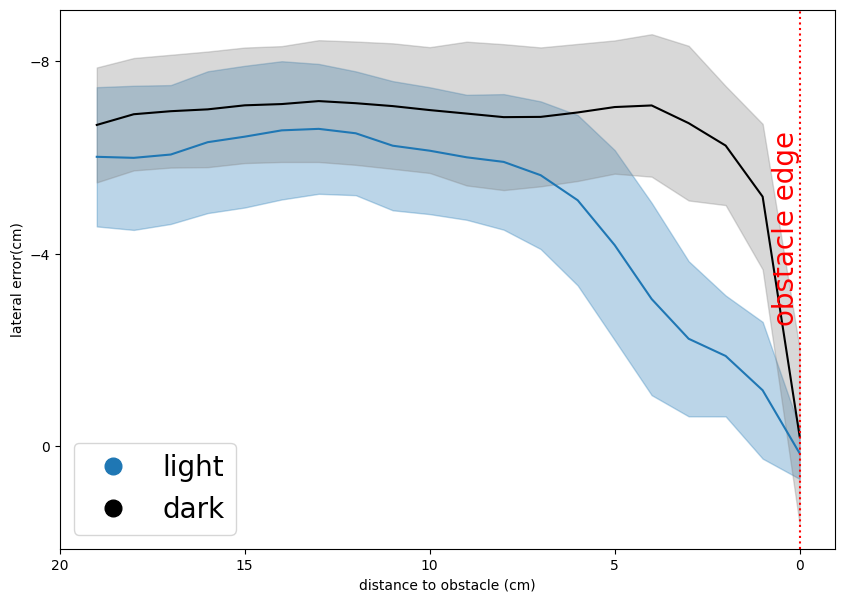

In [267]:
xnew =  np.arange(0, 20, 1)
xnew= np.flip(xnew)
fig,ax = plt.subplots(figsize = (10,7) )

ax.invert_xaxis()
ax.invert_yaxis()
data = pd.concat([joint])
data = drop_nans_in_columns(data,'obstacle_ind')
data = drop_nans_in_columns(data,'lateral_error')
data = data[data.turn_to_obstacle == 'towards']
#ts_angle_to_open_corner(data)
#zero_out_angle(data)
light_medians = []
dark_medians = []
light_sd = []
dark_sd = []
for task,task_df in  data.groupby(['task']):
  
    rows = task_df.shape[0]
    angle_array = np.empty([rows,len(xnew)])
    angle_array[:] =np.nan 
    for i,row in enumerate(task_df.iterrows()):
        x = row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])].astype(float)
        y = row[1]['lateral_error'][:int(row[1]['obstacle_ind'])].astype(float)
        if sum(y) == 0:
            continue
        else:
            interpolater = interp1d(x,y,bounds_error=False)
            ynew = interpolater(xnew)
            angle_array[i] = ynew

    
    task_angle_median= np.nanmedian(angle_array,axis = 0)

 
    if task == 'oa':
        light_array = angle_array
        light_angle_median= np.nanmedian(angle_array,axis = 0)
        ax.plot(xnew,task_angle_median,c = 'tab:blue',alpha = 1)
    else:
        dark_array = angle_array
        dark_angle_median= np.nanmedian(angle_array,axis = 0)
        ax.plot(xnew,dark_angle_median,c = 'black',alpha = 1)

    for animal,animal_df in task_df.groupby(['animal']):
        rows = animal_df.shape[0]
        angle_array = np.empty([rows,len(xnew)])
        angle_array[:] =np.nan 
        for i,row in enumerate(animal_df.iterrows()):
            x = row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])].astype(float)
            y = row[1]['lateral_error'][:int(row[1]['obstacle_ind'])].astype(float)
            if sum(y) == 0:
                continue
            else:
                interpolater = interp1d(x,y,bounds_error=False)
                ynew = interpolater(xnew)
                angle_array[i] = ynew
        animal_angle_median= np.nanmedian(angle_array,axis = 0)
        if animal_df.task.unique() == 'oa':
            light_medians.append(animal_angle_median)
        else:
            dark_medians.append(animal_angle_median)

light_medians = np.asarray(light_medians)
dark_medians = np.asarray(dark_medians)

for i in list(range(light_medians.shape[1])):
    sd = np.nanstd(light_medians[:,i])
    light_sd.append(sd)
light_sd = np.asarray(light_sd)

for i in list(range(dark_medians.shape[1])):
    sd = np.nanstd(dark_medians[:,i])
    dark_sd.append(sd)
dark_sd = np.asarray(dark_sd)

            






ax.fill_between(xnew, light_angle_median-light_sd, light_angle_median+light_sd, color='tab:blue', alpha=0.3, label='IQR')   
ax.fill_between(xnew, dark_angle_median-dark_sd, dark_angle_median+dark_sd, color='tab:grey', alpha=0.3, label='IQR')  
ax.set_xticks([20,15,10,5,0])    
ax.set_yticks([-8,-4,0]) 
ax.set_ylabel('lateral error(cm)')
ax.set_xlabel('distance to obstacle (cm)')
ax.axvline(0, color='r', ls=':')
ax.text(0, ax.get_ylim()[1]/2,'obstacle edge', color='r', ha='right', va='center', rotation=90,fontsize=20)
   
markers = [plt.Line2D([0,0],[0,0],color=color, marker='o', linestyle='',markersize=12) for color in ['tab:blue','black']]
ax.legend(markers, ['light','dark'], numpoints=1,loc = 'lower left',fontsize=20)

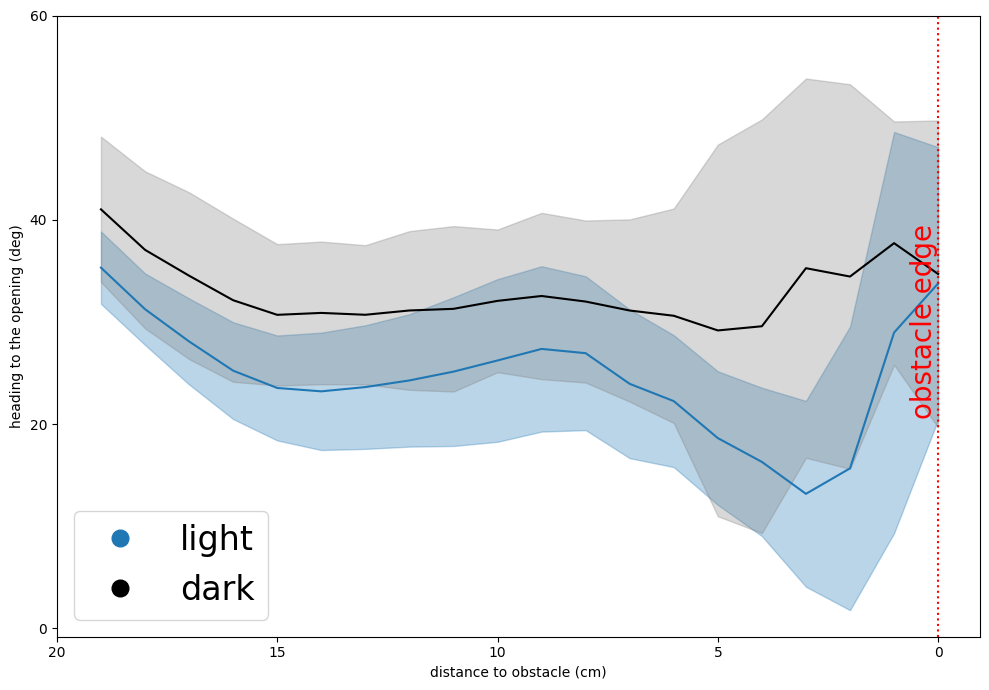

In [246]:
xnew =  np.arange(0, 20, 1)
xnew= np.flip(xnew)
fig,ax = plt.subplots(layout = 'tight',figsize = (10,7) )

ax.invert_xaxis()
data = pd.concat([long_nostart])
data = drop_nans_in_columns(data,'obstacle_ind')
data = data[data.turn_to_obstacle == 'away']
#zero_out_angle(data)
#ts_angle_to_open_corner(data)
#zero_out_angle(data)
light_medians = []
dark_medians = []
light_sd = []
dark_sd = []
for task,task_df in  data.groupby(['task']):
  
    rows = task_df.shape[0]
    angle_array = np.empty([rows,len(xnew)])
    angle_array[:] =np.nan 
    for i,row in enumerate(task_df.iterrows()):
        x = row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])].astype(float)
        y = row[1]['ts_angle_to_corner'][:int(row[1]['obstacle_ind'])].astype(float)
        if sum(y) == 0:
            continue
        else:
            interpolater = interp1d(x,y,bounds_error=False)
            ynew = interpolater(xnew)
            angle_array[i] = ynew

    
    task_angle_median= np.nanmedian(angle_array,axis = 0)

 
    if task == 'oa':
        light_array = angle_array
        light_angle_median= np.nanmedian(angle_array,axis = 0)
        ax.plot(xnew,light_angle_median,c = 'tab:blue',alpha = 1)
    else:
        dark_array = angle_array
        dark_angle_median= np.nanmedian(angle_array,axis = 0)
        ax.plot(xnew,dark_angle_median,c = 'black',alpha = 1)

    for animal,animal_df in task_df.groupby(['animal']):
        rows = animal_df.shape[0]
        angle_array = np.empty([rows,len(xnew)])
        angle_array[:] =np.nan 
        for i,row in enumerate(animal_df.iterrows()):
            x = row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])].astype(float)
            y = row[1]['ts_angle_to_corner'][:int(row[1]['obstacle_ind'])].astype(float)
            if sum(y) == 0:
                continue
            else:
                interpolater = interp1d(x,y,bounds_error=False)
                ynew = interpolater(xnew)
                angle_array[i] = ynew
        animal_angle_median= np.nanmedian(angle_array,axis = 0)
        if animal_df.task.unique() == 'oa':
            #ax.plot(xnew,animal_angle_median,c = 'tab:blue',alpha = .25)
            light_medians.append(animal_angle_median)
            
        else:
            dark_medians.append(animal_angle_median)
            #ax.plot(xnew,animal_angle_median,c = 'black',alpha = .25)

light_medians = np.asarray(light_medians)
dark_medians = np.asarray(dark_medians)

for i in list(range(light_medians.shape[1])):
    sd = np.nanstd(light_medians[:,i])
    light_sd.append(sd)
light_sd = np.asarray(light_sd)

for i in list(range(dark_medians.shape[1])):
    sd = np.nanstd(dark_medians[:,i])
    dark_sd.append(sd)
dark_sd = np.asarray(dark_sd)

            






ax.fill_between(xnew, light_angle_median-light_sd, light_angle_median+light_sd, color='tab:blue', alpha=0.3, label='IQR')   
ax.fill_between(xnew, dark_angle_median-dark_sd, dark_angle_median+dark_sd, color='tab:grey', alpha=0.3, label='IQR')  
ax.set_xticks([20,15,10,5,0])    
ax.set_yticks([0,20,40,60])  
ax.set_ylabel('heading to the opening (deg)')
ax.set_xlabel('distance to obstacle (cm)')
ax.axvline(0, color='r', ls=':')
ax.text(0, ax.get_ylim()[1]/2,'obstacle edge', color='r', ha='right', va='center', rotation=90,fontsize=20)
   
markers = [plt.Line2D([0,0],[0,0],color=color, marker='o', linestyle='',markersize=12) for color in ['tab:blue','black']]
ax.legend(markers, ['light','dark'], numpoints=1,loc = 'lower left',fontsize=24)

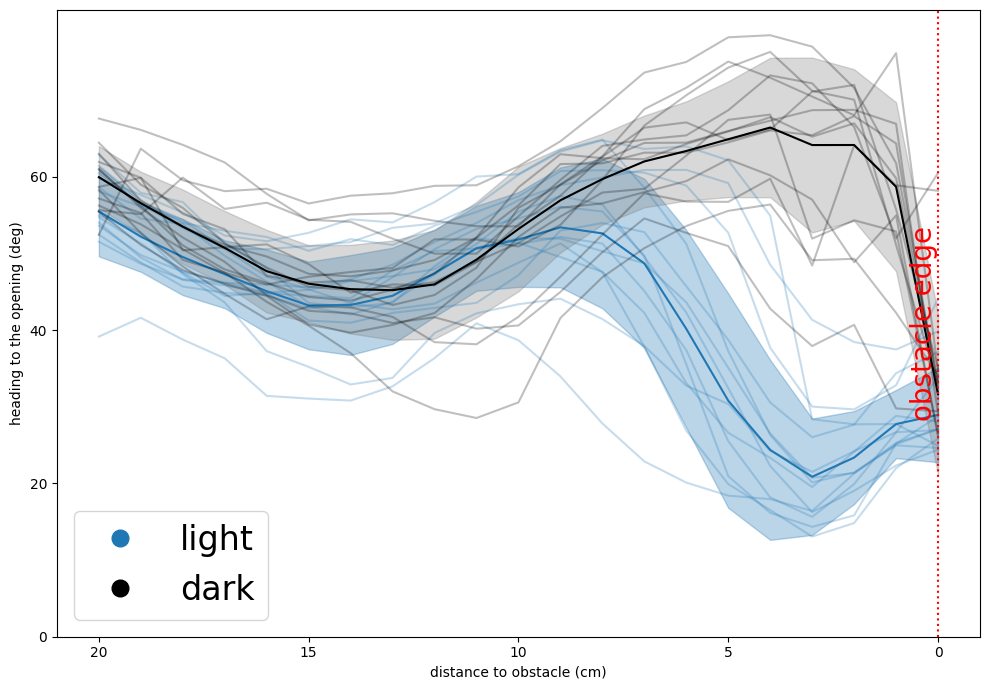

In [247]:
xnew =  np.arange(0, 21, 1)
xnew= np.flip(xnew)
fig,ax = plt.subplots(layout = 'tight',figsize = (10,7) )

ax.invert_xaxis()
data = pd.concat([joint])
data = drop_nans_in_columns(data,'obstacle_ind')
data = data[data.turn_to_obstacle == 'towards']
#zero_out_angle(data)
#ts_angle_to_open_corner(data)
#zero_out_angle(data)
light_medians = []
dark_medians = []
light_sd = []
dark_sd = []
for task,task_df in  data.groupby(['task']):
  
    rows = task_df.shape[0]
    angle_array = np.empty([rows,len(xnew)])
    angle_array[:] =np.nan 
    for i,row in enumerate(task_df.iterrows()):
        x = row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])].astype(float)
        y = row[1]['ts_angle_to_corner'][:int(row[1]['obstacle_ind'])].astype(float)
        if sum(y) == 0:
            continue
        else:
            interpolater = interp1d(x,y,bounds_error=False)
            ynew = interpolater(xnew)
            angle_array[i] = ynew

    
    task_angle_median= np.nanmedian(angle_array,axis = 0)

 
    if task == 'oa':
        light_array = angle_array
        light_angle_median= np.nanmedian(angle_array,axis = 0)
        ax.plot(xnew,light_angle_median,c = 'tab:blue',alpha = 1)
    else:
        dark_array = angle_array
        dark_angle_median= np.nanmedian(angle_array,axis = 0)
        ax.plot(xnew,dark_angle_median,c = 'black',alpha = 1)

    for animal,animal_df in task_df.groupby(['animal']):
        rows = animal_df.shape[0]
        angle_array = np.empty([rows,len(xnew)])
        angle_array[:] =np.nan 
        for i,row in enumerate(animal_df.iterrows()):
            x = row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])].astype(float)
            y = row[1]['ts_angle_to_corner'][:int(row[1]['obstacle_ind'])].astype(float)
            if sum(y) == 0:
                continue
            else:
                interpolater = interp1d(x,y,bounds_error=False)
                ynew = interpolater(xnew)
                angle_array[i] = ynew
        animal_angle_median= np.nanmedian(angle_array,axis = 0)
        if animal_df.task.unique() == 'oa':
            ax.plot(xnew,animal_angle_median,c = 'tab:blue',alpha = .25)
            light_medians.append(animal_angle_median)
            
        else:
            dark_medians.append(animal_angle_median)
            ax.plot(xnew,animal_angle_median,c = 'black',alpha = .25)

light_medians = np.asarray(light_medians)
dark_medians = np.asarray(dark_medians)

for i in list(range(light_medians.shape[1])):
    sd = np.nanstd(light_medians[:,i])
    light_sd.append(sd)
light_sd = np.asarray(light_sd)

for i in list(range(dark_medians.shape[1])):
    sd = np.nanstd(dark_medians[:,i])
    dark_sd.append(sd)
dark_sd = np.asarray(dark_sd)

            






ax.fill_between(xnew, light_angle_median-light_sd, light_angle_median+light_sd, color='tab:blue', alpha=0.3, label='IQR')   
ax.fill_between(xnew, dark_angle_median-dark_sd, dark_angle_median+dark_sd, color='tab:grey', alpha=0.3, label='IQR')  
ax.set_xticks([20,15,10,5,0])    
ax.set_yticks([0,20,40,60])  
ax.set_ylabel('heading to the opening (deg)')
ax.set_xlabel('distance to obstacle (cm)')
ax.axvline(0, color='r', ls=':')
ax.text(0, ax.get_ylim()[1]/2,'obstacle edge', color='r', ha='right', va='center', rotation=90,fontsize=20)
   
markers = [plt.Line2D([0,0],[0,0],color=color, marker='o', linestyle='',markersize=12) for color in ['tab:blue','black']]
ax.legend(markers, ['light','dark'], numpoints=1,loc = 'lower left',fontsize=24)

In [85]:
dark.animal.unique()

array(['J704RT', 'J704NN', 'J704LT', 'J704LN', 'G8CK1RT', 'G8CK1LT',
       'G8CK1TT', 'G8CK1LN', 'G8CKRT', 'G8CKLT', 'G8CKTT', 'G8CKRN',
       'G8CKLN'], dtype=object)

In [84]:
light.animal.unique()

array(['J701LT', 'J701RT', 'J701NN', 'J701RN', 'G8CK1RT', 'G8CK1LT',
       'G8CK1TT', 'G8CK1LN', 'G8CKRT', 'G8CKLT', 'G8CKTT', 'G8CKRN',
       'G8CKLN'], dtype=object)

In [87]:
data = pd.concat([joint])
animals_to_drop = [ 'J704RT', 'J704NN', 'J704LT', 'J704LN','J701LT', 'J701RT', 'J701NN', 'J701RN']
data = data[~data.animal.isin(animals_to_drop)]
data.animal.unique()

array(['G8CK1RT', 'G8CK1LT', 'G8CK1TT', 'G8CK1LN', 'G8CKRT', 'G8CKLT',
       'G8CKTT', 'G8CKRN', 'G8CKLN'], dtype=object)

In [179]:
np.arange(0, 21, 1)[0]

0

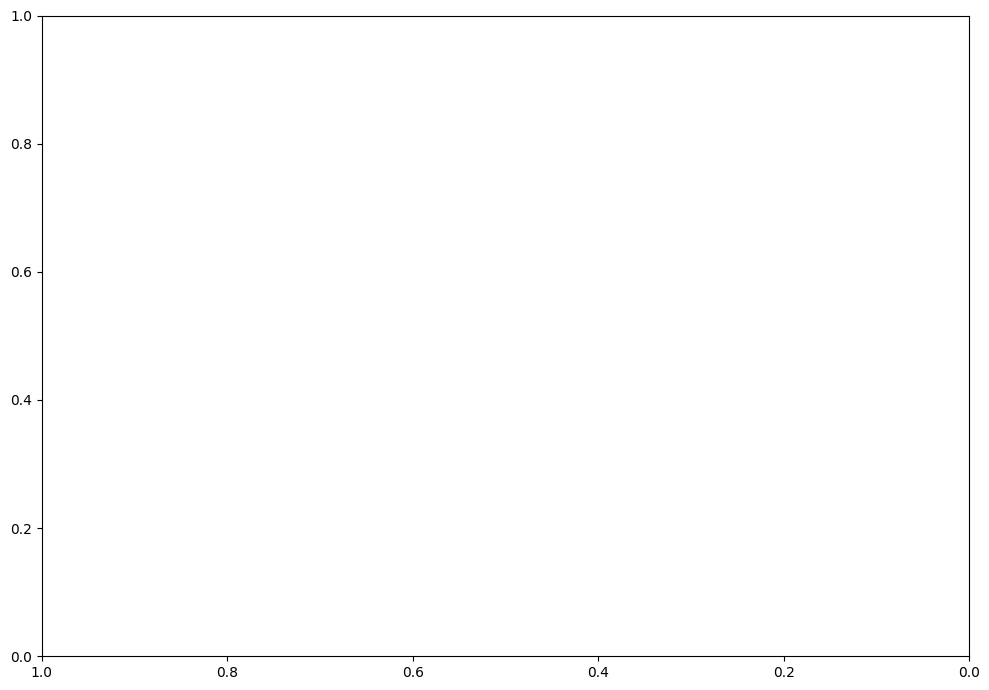

In [258]:
xnew =  np.arange(0, 21, 1)
xnew= np.flip(xnew)
fig,ax = plt.subplots(layout = 'tight',figsize = (10,7) )

ax.invert_xaxis()
data = pd.concat([joint])
animals_to_drop = [ 'J704RT', 'J704NN', 'J704LT', 'J704LN','J701LT', 'J701RT', 'J701NN', 'J701RN']
data = data[~data.animal.isin(animals_to_drop)]
data = drop_nans_in_columns(data,'obstacle_ind')
data = data[data.turn_to_obstacle == 'towards']
#zero_out_angle(data)
#ts_angle_to_open_corner(data)
#zero_out_angle(data)
light_medians = []
dark_medians = []

for animal,animal_df in  data.groupby(['animal']):
    for task,task_df in  animal_df.groupby(['task']):
        rows = task_df.shape[0]
        angle_array = np.empty([rows,len(xnew)])
        angle_array[:] =np.nan 
        for i,row in enumerate(task_df.iterrows()):
            x = row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])].astype(float)
            y = row[1]['ts_angle_to_corner'][:int(row[1]['obstacle_ind'])].astype(float)
            if sum(y) == 0:
                continue
            else:
                interpolater = interp1d(x,y,bounds_error=False)
                ynew = interpolater(xnew)
                angle_array[i] = ynew


        task_angle_median= np.nanmedian(angle_array,axis = 0)

    
        if task == 'oa':
            light_array = angle_array
            light_angle_median= np.nanmedian(angle_array,axis = 0)
            light_medians.append(light_angle_median)
            #ax.plot(xnew,light_angle_median,c = 'tab:blue',alpha = 1)
        else:
            dark_array = angle_array
            dark_angle_median= np.nanmedian(angle_array,axis = 0)
            dark_medians.append(dark_angle_median)
            #ax.plot(xnew,dark_angle_median,c = 'black',alpha = 1)

light_medians = np.asarray(light_medians)
dark_medians = np.asarray(dark_medians)


        

In [204]:
import statsmodels.api as sm
from statsmodels.formula.api import ols

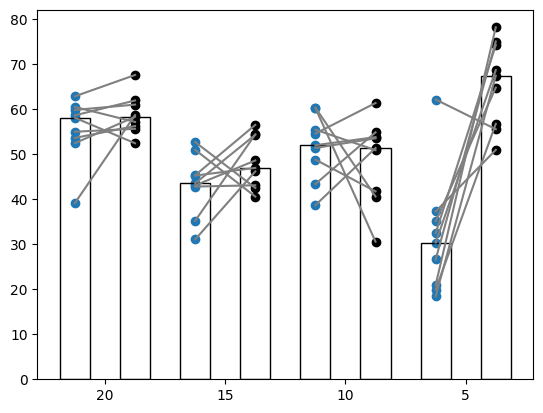

In [259]:
fig,ax = plt.subplots()
ax.set_xticks([.5,2.5,4.5,6.5],[20,15,10,5])

ax.scatter(np.full(light_medians.shape[0],0),light_medians[:,0],color = 'tab:blue')
ax.bar(0,np.nanmedian(light_medians[:,0]),fill = False,color = 'tab:blue',width=.5)
ax.scatter(np.full(dark_medians.shape[0],1),dark_medians[:,0],color = 'black')
ax.bar(1,np.nanmedian(dark_medians[:,0]),fill = False,color = 'tab:blue',width=.5)
ax.plot((np.full(light_medians.shape[0],0),np.full(dark_medians.shape[0],1)),(light_medians[:,0],dark_medians[:,0]),color = 'grey')


ax.scatter(np.full(light_medians.shape[0],2),light_medians[:,5],color = 'tab:blue')
ax.bar(2,np.nanmedian(light_medians[:,5]),fill = False,color = 'tab:blue',width=.5)
ax.scatter(np.full(dark_medians.shape[0],3),dark_medians[:,5],color = 'black')
ax.bar(3,np.nanmedian(dark_medians[:,5]),fill = False,color = 'tab:blue',width=.5)
ax.plot((np.full(light_medians.shape[0],2),np.full(dark_medians.shape[0],3)),(light_medians[:,5],dark_medians[:,5]),color = 'grey')

ax.scatter(np.full(light_medians.shape[0],4),light_medians[:,10],color = 'tab:blue')
ax.bar(4,np.nanmedian(light_medians[:,10]),fill = False,color = 'tab:blue',width=.5)
ax.scatter(np.full(dark_medians.shape[0],5),dark_medians[:,10],color = 'black')
ax.bar(5,np.nanmedian(dark_medians[:,10]),fill = False,color = 'tab:blue',width=.5)
ax.plot((np.full(light_medians.shape[0],4),np.full(dark_medians.shape[0],5)),(light_medians[:,10],dark_medians[:,10]),color = 'grey')

ax.scatter(np.full(light_medians.shape[0],6),light_medians[:,15],color = 'tab:blue')
ax.bar(6,np.nanmedian(light_medians[:,15]),fill = False,color = 'tab:blue',width=.5)
ax.scatter(np.full(dark_medians.shape[0],7),dark_medians[:,15],color = 'black')
ax.bar(7,np.nanmedian(dark_medians[:,15]),fill = False,color = 'tab:blue',width=.5)
ax.plot((np.full(light_medians.shape[0],6),np.full(dark_medians.shape[0],7)),(light_medians[:,15],dark_medians[:,15]),color = 'grey')





In [218]:
stats.ks_2samp(dark_medians[:,15],light_medians[:,15])

KstestResult(statistic=0.8461538461538461, pvalue=6.249639443878237e-05, statistic_location=49.98063489322999, statistic_sign=-1)

In [260]:
import numpy as np
from scipy.stats import f_oneway
f_oneway(dark_medians[:,15],light_medians[:,15])



F_onewayResult(statistic=39.17943201493036, pvalue=1.1397234733442407e-05)

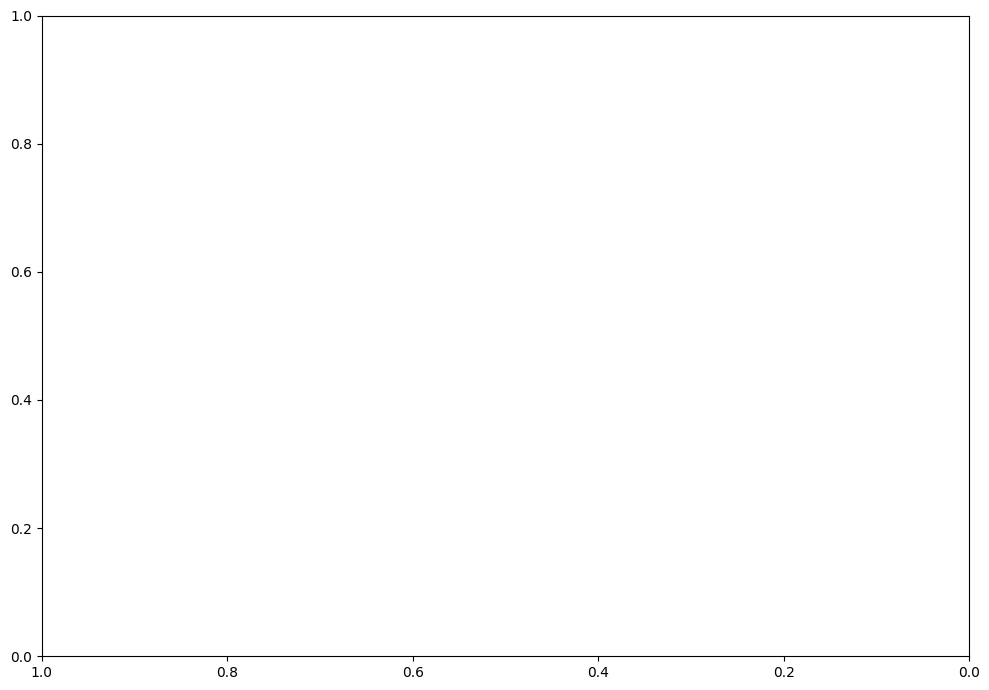

In [261]:
xnew =  np.arange(0, 21, 1)
xnew= np.flip(xnew)
fig,ax = plt.subplots(layout = 'tight',figsize = (10,7) )

ax.invert_xaxis()
data = pd.concat([shor])
animals_to_drop = [ 'J704RT', 'J704NN', 'J704LT', 'J704LN','J701LT', 'J701RT', 'J701NN', 'J701RN']
data = data[~data.animal.isin(animals_to_drop)]
data = drop_nans_in_columns(data,'obstacle_ind')
data = drop_nans_in_columns(data,'lateral_error')
data = data[data.turn_to_obstacle == 'towards']
#zero_out_angle(data)
#ts_angle_to_open_corner(data)
#zero_out_angle(data)
light_medians = []
dark_medians = []

for animal,animal_df in  data.groupby(['animal']):
    for task,task_df in  animal_df.groupby(['task']):
        rows = task_df.shape[0]
        angle_array = np.empty([rows,len(xnew)])
        angle_array[:] =np.nan 
        for i,row in enumerate(task_df.iterrows()):
            x = row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])].astype(float)
            y = row[1]['lateral_error'][:int(row[1]['obstacle_ind'])].astype(float)
            if sum(y) == 0:
                continue
            else:
                interpolater = interp1d(x,y,bounds_error=False)
                ynew = interpolater(xnew)
                angle_array[i] = ynew


        task_angle_median= np.nanmedian(angle_array,axis = 0)

    
        if task == 'oa':
            light_array = angle_array
            light_angle_median= np.nanmedian(angle_array,axis = 0)
            light_medians.append(light_angle_median)
            #ax.plot(xnew,light_angle_median,c = 'tab:blue',alpha = 1)
        else:
            dark_array = angle_array
            dark_angle_median= np.nanmedian(angle_array,axis = 0)
            dark_medians.append(dark_angle_median)
            #ax.plot(xnew,dark_angle_median,c = 'black',alpha = 1)

light_medians = np.asarray(light_medians)
dark_medians = np.asarray(dark_medians)

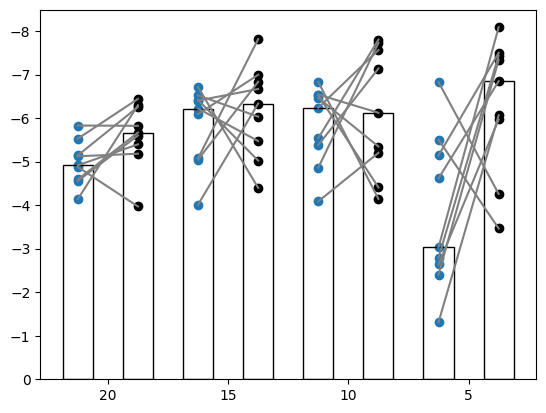

In [262]:
fig,ax = plt.subplots()
ax.set_xticks([.5,2.5,4.5,6.5],[20,15,10,5])

ax.scatter(np.full(light_medians.shape[0],0),light_medians[:,0],color = 'tab:blue')
ax.bar(0,np.nanmedian(light_medians[:,0]),fill = False,color = 'tab:blue',width=.5)
ax.scatter(np.full(dark_medians.shape[0],1),dark_medians[:,0],color = 'black')
ax.bar(1,np.nanmedian(dark_medians[:,0]),fill = False,color = 'tab:blue',width=.5)
ax.plot((np.full(light_medians.shape[0],0),np.full(dark_medians.shape[0],1)),(light_medians[:,0],dark_medians[:,0]),color = 'grey')


ax.scatter(np.full(light_medians.shape[0],2),light_medians[:,5],color = 'tab:blue')
ax.bar(2,np.nanmedian(light_medians[:,5]),fill = False,color = 'tab:blue',width=.5)
ax.scatter(np.full(dark_medians.shape[0],3),dark_medians[:,5],color = 'black')
ax.bar(3,np.nanmedian(dark_medians[:,5]),fill = False,color = 'tab:blue',width=.5)
ax.plot((np.full(light_medians.shape[0],2),np.full(dark_medians.shape[0],3)),(light_medians[:,5],dark_medians[:,5]),color = 'grey')

ax.scatter(np.full(light_medians.shape[0],4),light_medians[:,10],color = 'tab:blue')
ax.bar(4,np.nanmedian(light_medians[:,10]),fill = False,color = 'tab:blue',width=.5)
ax.scatter(np.full(dark_medians.shape[0],5),dark_medians[:,10],color = 'black')
ax.bar(5,np.nanmedian(dark_medians[:,10]),fill = False,color = 'tab:blue',width=.5)
ax.plot((np.full(light_medians.shape[0],4),np.full(dark_medians.shape[0],5)),(light_medians[:,10],dark_medians[:,10]),color = 'grey')

ax.scatter(np.full(light_medians.shape[0],6),light_medians[:,15],color = 'tab:blue')
ax.bar(6,np.nanmedian(light_medians[:,15]),fill = False,color = 'tab:blue',width=.5)
ax.scatter(np.full(dark_medians.shape[0],7),dark_medians[:,15],color = 'black')
ax.bar(7,np.nanmedian(dark_medians[:,15]),fill = False,color = 'tab:blue',width=.5)
ax.plot((np.full(light_medians.shape[0],6),np.full(dark_medians.shape[0],7)),(light_medians[:,15],dark_medians[:,15]),color = 'grey')
ax.invert_yaxis()

In [263]:

f_oneway(dark_medians[:,15],light_medians[:,15])

F_onewayResult(statistic=10.107399974528644, pvalue=0.005826677470858147)

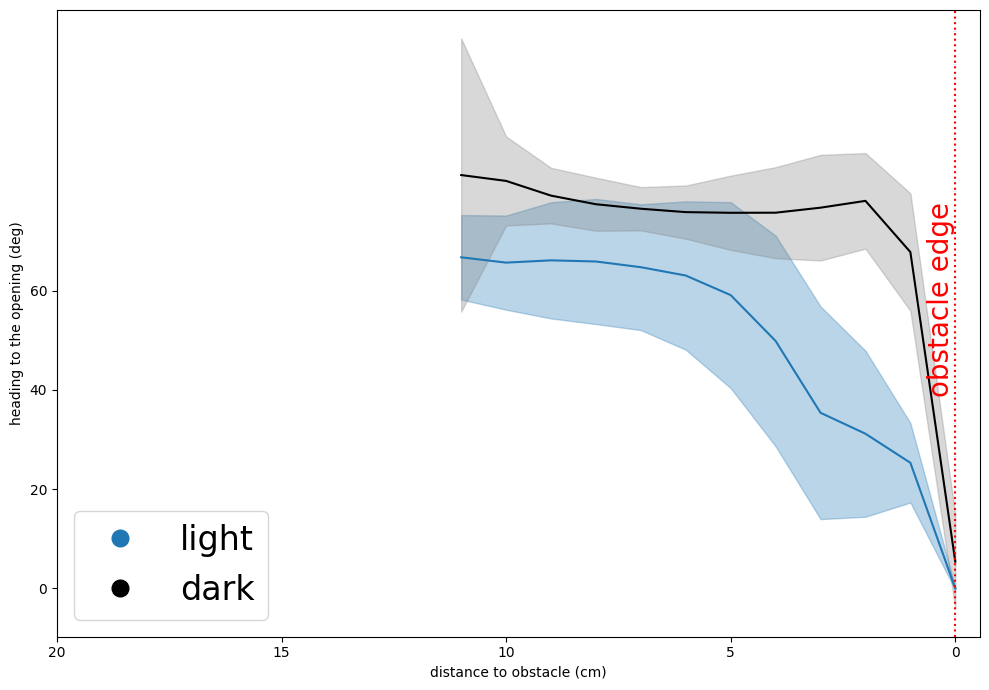

In [66]:
xnew =  np.arange(0, 12, 1)
xnew= np.flip(xnew)
fig,ax = plt.subplots(layout = 'tight',figsize = (10,7) )

ax.invert_xaxis()
data = pd.concat([short_nostart])
data = drop_nans_in_columns(data,'obstacle_ind')
data = data[data.turn_to_obstacle == 'towards']
#zero_out_angle(data)
#ts_angle_to_open_corner(data)
#zero_out_angle(data)
light_medians = []
dark_medians = []
light_sd = []
dark_sd = []
for task,task_df in  data.groupby(['task']):
  
    rows = task_df.shape[0]
    angle_array = np.empty([rows,len(xnew)])
    angle_array[:] =np.nan 
    for i,row in enumerate(task_df.iterrows()):
        x = row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])].astype(float)
        y = row[1]['ts_zero_out_angle_to_corner'][:int(row[1]['obstacle_ind'])].astype(float)
        if sum(y) == 0:
            continue
        else:
            interpolater = interp1d(x,y,bounds_error=False)
            ynew = interpolater(xnew)
            angle_array[i] = ynew

    
    task_angle_median= np.nanmedian(angle_array,axis = 0)

 
    if task == 'oa':
        light_array = angle_array
        light_angle_median= np.nanmedian(angle_array,axis = 0)
        ax.plot(xnew,light_angle_median,c = 'tab:blue',alpha = 1)
    else:
        dark_array = angle_array
        dark_angle_median= np.nanmedian(angle_array,axis = 0)
        ax.plot(xnew,dark_angle_median,c = 'black',alpha = 1)

    for animal,animal_df in task_df.groupby(['animal']):
        rows = animal_df.shape[0]
        angle_array = np.empty([rows,len(xnew)])
        angle_array[:] =np.nan 
        for i,row in enumerate(animal_df.iterrows()):
            x = row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])].astype(float)
            y = row[1]['ts_zero_out_angle_to_corner'][:int(row[1]['obstacle_ind'])].astype(float)
            if sum(y) == 0:
                continue
            else:
                interpolater = interp1d(x,y,bounds_error=False)
                ynew = interpolater(xnew)
                angle_array[i] = ynew
        animal_angle_median= np.nanmedian(angle_array,axis = 0)
        if animal_df.task.unique() == 'oa':
            light_medians.append(animal_angle_median)
            
        else:
            dark_medians.append(animal_angle_median)

light_medians = np.asarray(light_medians)
dark_medians = np.asarray(dark_medians)

for i in list(range(light_medians.shape[1])):
    sd = np.nanstd(light_medians[:,i])
    light_sd.append(sd)
light_sd = np.asarray(light_sd)

for i in list(range(dark_medians.shape[1])):
    sd = np.nanstd(dark_medians[:,i])
    dark_sd.append(sd)
dark_sd = np.asarray(dark_sd)

            






ax.fill_between(xnew, light_angle_median-light_sd, light_angle_median+light_sd, color='tab:blue', alpha=0.3, label='IQR')   
ax.fill_between(xnew, dark_angle_median-dark_sd, dark_angle_median+dark_sd, color='tab:grey', alpha=0.3, label='IQR')  
ax.set_xticks([20,15,10,5,0])    
ax.set_yticks([0,20,40,60])  
ax.set_ylabel('heading to the opening (deg)')
ax.set_xlabel('distance to obstacle (cm)')
ax.axvline(0, color='r', ls=':')
ax.text(0, ax.get_ylim()[1]/2,'obstacle edge', color='r', ha='right', va='center', rotation=90,fontsize=20)
   
markers = [plt.Line2D([0,0],[0,0],color=color, marker='o', linestyle='',markersize=12) for color in ['tab:blue','black']]
ax.legend(markers, ['light','dark'], numpoints=1,loc = 'lower left',fontsize=24)

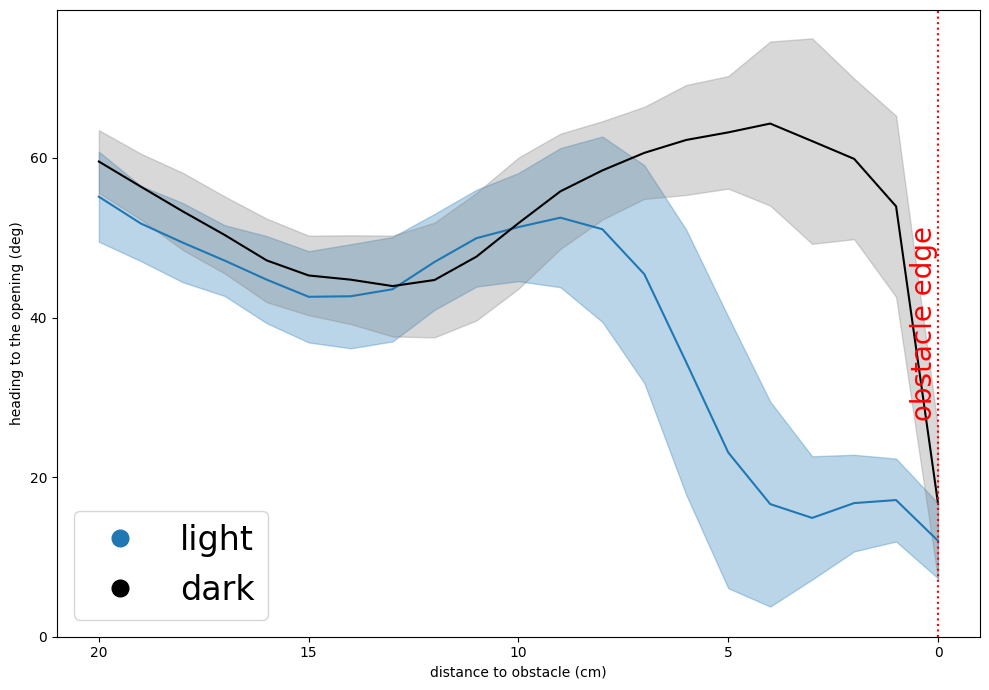

In [256]:
xnew =  np.arange(0, 21, 1)
xnew= np.flip(xnew)
fig,ax = plt.subplots(layout = 'tight',figsize = (10,7) )

ax.invert_xaxis()
data = pd.concat([joint])
data = drop_nans_in_columns(data,'obstacle_ind')
data = data[data.turn_to_obstacle == 'towards']
#zero_out_angle(data)
#ts_angle_to_open_corner(data)
#zero_out_angle(data)
light_medians = []
dark_medians = []
light_sd = []
dark_sd = []
for task,task_df in  data.groupby(['task']):
  
    rows = task_df.shape[0]
    angle_array = np.empty([rows,len(xnew)])
    angle_array[:] =np.nan 
    for i,row in enumerate(task_df.iterrows()):
        x = row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])].astype(float)
        y = row[1]['ts_zero_out_angle_to_corner'][:int(row[1]['obstacle_ind'])].astype(float)
        if sum(y) == 0:
            continue
        else:
            interpolater = interp1d(x,y,bounds_error=False)
            ynew = interpolater(xnew)
            angle_array[i] = ynew

    
    task_angle_median= np.nanmedian(angle_array,axis = 0)

 
    if task == 'oa':
        light_array = angle_array
        light_angle_median= np.nanmedian(angle_array,axis = 0)
        ax.plot(xnew,light_angle_median,c = 'tab:blue',alpha = 1)
    else:
        dark_array = angle_array
        dark_angle_median= np.nanmedian(angle_array,axis = 0)
        ax.plot(xnew,dark_angle_median,c = 'black',alpha = 1)

    for animal,animal_df in task_df.groupby(['animal']):
        rows = animal_df.shape[0]
        angle_array = np.empty([rows,len(xnew)])
        angle_array[:] =np.nan 
        for i,row in enumerate(animal_df.iterrows()):
            x = row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])].astype(float)
            y = row[1]['ts_zero_out_angle_to_corner'][:int(row[1]['obstacle_ind'])].astype(float)
            if sum(y) == 0:
                continue
            else:
                interpolater = interp1d(x,y,bounds_error=False)
                ynew = interpolater(xnew)
                angle_array[i] = ynew
        animal_angle_median= np.nanmedian(angle_array,axis = 0)
        if animal_df.task.unique() == 'oa':
            light_medians.append(animal_angle_median)
            
        else:
            dark_medians.append(animal_angle_median)

light_medians = np.asarray(light_medians)
dark_medians = np.asarray(dark_medians)

for i in list(range(light_medians.shape[1])):
    sd = np.nanstd(light_medians[:,i])
    light_sd.append(sd)
light_sd = np.asarray(light_sd)

for i in list(range(dark_medians.shape[1])):
    sd = np.nanstd(dark_medians[:,i])
    dark_sd.append(sd)
dark_sd = np.asarray(dark_sd)

            






ax.fill_between(xnew, light_angle_median-light_sd, light_angle_median+light_sd, color='tab:blue', alpha=0.3, label='IQR')   
ax.fill_between(xnew, dark_angle_median-dark_sd, dark_angle_median+dark_sd, color='tab:grey', alpha=0.3, label='IQR')  
ax.set_xticks([20,15,10,5,0])    
ax.set_yticks([0,20,40,60])  
ax.set_ylabel('heading to the opening (deg)')
ax.set_xlabel('distance to obstacle (cm)')
ax.axvline(0, color='r', ls=':')
ax.text(0, ax.get_ylim()[1]/2,'obstacle edge', color='r', ha='right', va='center', rotation=90,fontsize=20)
   
markers = [plt.Line2D([0,0],[0,0],color=color, marker='o', linestyle='',markersize=12) for color in ['tab:blue','black']]
ax.legend(markers, ['light','dark'], numpoints=1,loc = 'lower left',fontsize=24)

In [19]:
from scipy import stats

(array([ 82.,  91., 241., 417., 293.,  65.,   7.,   2.,   0.,   2.]),
 array([  0.        ,  16.36328322,  32.72656644,  49.08984966,
         65.45313288,  81.81641609,  98.17969931, 114.54298253,
        130.90626575, 147.26954897, 163.63283219]),
 <BarContainer object of 10 artists>)

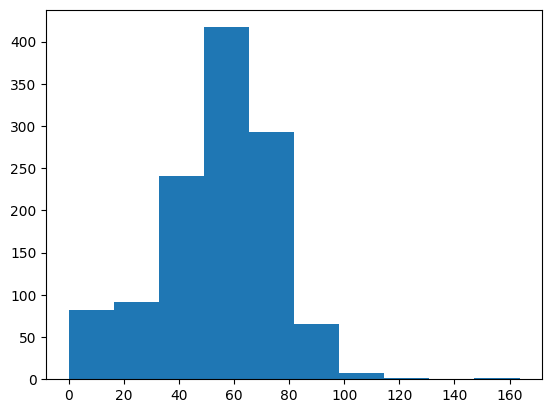

In [17]:
plt.hist(dark_array[:,0])

In [78]:
stats.ks_2samp(dark_array[:,0], light_array[:,0])

KstestResult(statistic=0.07186132004740368, pvalue=3.414941524041259e-08, statistic_location=143.53982259739794, statistic_sign=1)

In [57]:
stats.ks_2samp(dark_medians[:,4], light_medians[:,4])

KstestResult(statistic=0.23076923076923078, pvalue=0.8978057035171046, statistic_location=45.314542758205526, statistic_sign=-1)

In [71]:
stats.ks_2samp(dark_medians[:,11], light_medians[:,11])

KstestResult(statistic=0.5384615384615384, pvalue=0.04427244582043343, statistic_location=41.472523482961456, statistic_sign=-1)

In [73]:
stats.ks_2samp(dark_medians[:,13], light_medians[:,13])

KstestResult(statistic=0.9230769230769231, pvalue=4.9997115551025895e-06, statistic_location=25.85360317257615, statistic_sign=-1)

In [74]:
stats.ks_2samp(dark_medians[:,19], light_medians[:,19])

KstestResult(statistic=0.3076923076923077, pvalue=0.5881960656115993, statistic_location=0.0, statistic_sign=-1)

(array([563., 162., 274., 541., 656., 319.,  69.,   6.,   3.,   2.]),
 array([  0.        ,  17.50817425,  35.0163485 ,  52.52452275,
         70.032697  ,  87.54087125, 105.0490455 , 122.55721975,
        140.065394  , 157.57356825, 175.0817425 ]),
 <BarContainer object of 10 artists>)

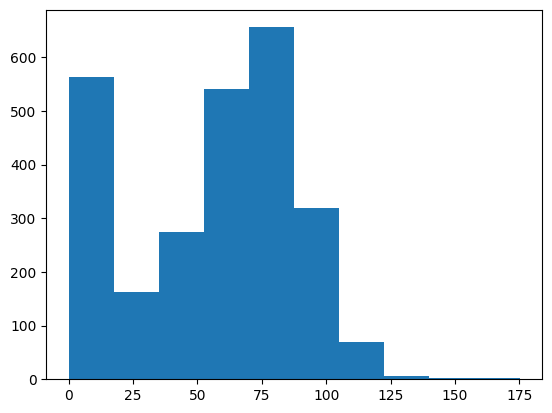

In [49]:
plt.hist(dark_array[:,15])

(array([140., 171., 589., 587., 150.,  21.,   4.,   5.,   0.,   3.]),
 array([  0.        ,  17.74762544,  35.49525088,  53.24287632,
         70.99050177,  88.73812721, 106.48575265, 124.23337809,
        141.98100353, 159.72862897, 177.47625441]),
 [<matplotlib.patches.Polygon at 0x2a7c7476640>])

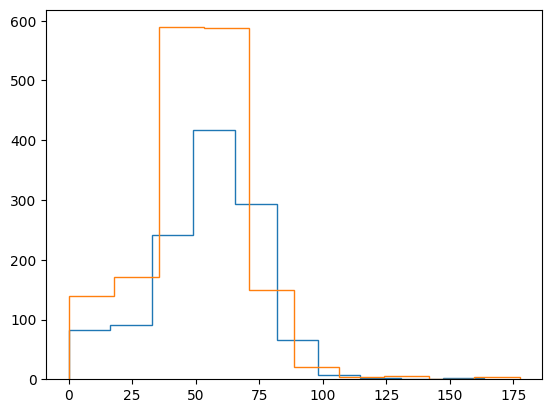

In [77]:
plt.hist(dark_array[:,1],histtype='step')
plt.hist(light_array[:,1],histtype='step')

(array([140., 171., 589., 587., 150.,  21.,   4.,   5.,   0.,   3.]),
 array([  0.        ,  17.74762544,  35.49525088,  53.24287632,
         70.99050177,  88.73812721, 106.48575265, 124.23337809,
        141.98100353, 159.72862897, 177.47625441]),
 <BarContainer object of 10 artists>)

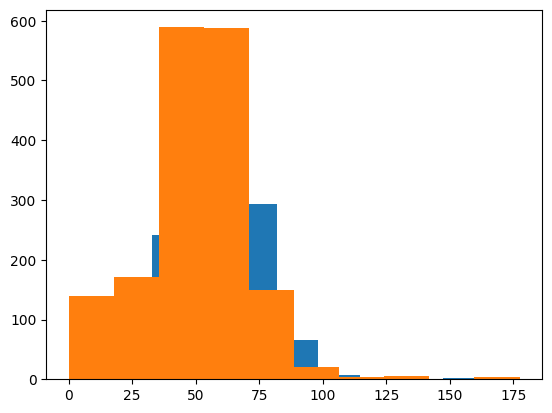

In [44]:
plt.hist(dark_array[:,0])
plt.hist(light_array[:,0])

(array([509., 366., 729., 542.,  77.,  28.,  11.,  12.,   9.,  10.]),
 array([  0.        ,  17.407387  ,  34.81477401,  52.22216101,
         69.62954802,  87.03693502, 104.44432203, 121.85170903,
        139.25909604, 156.66648304, 174.07387005]),
 <BarContainer object of 10 artists>)

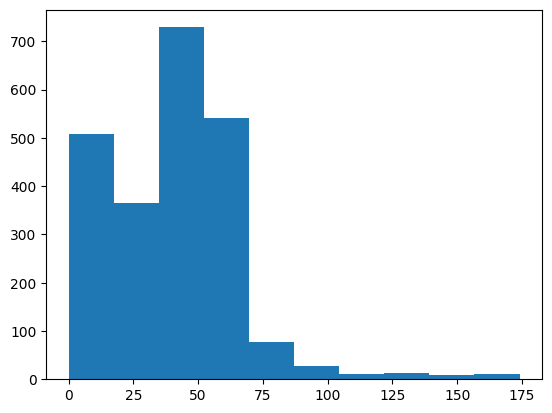

In [28]:
plt.hist(light_array[:,5])

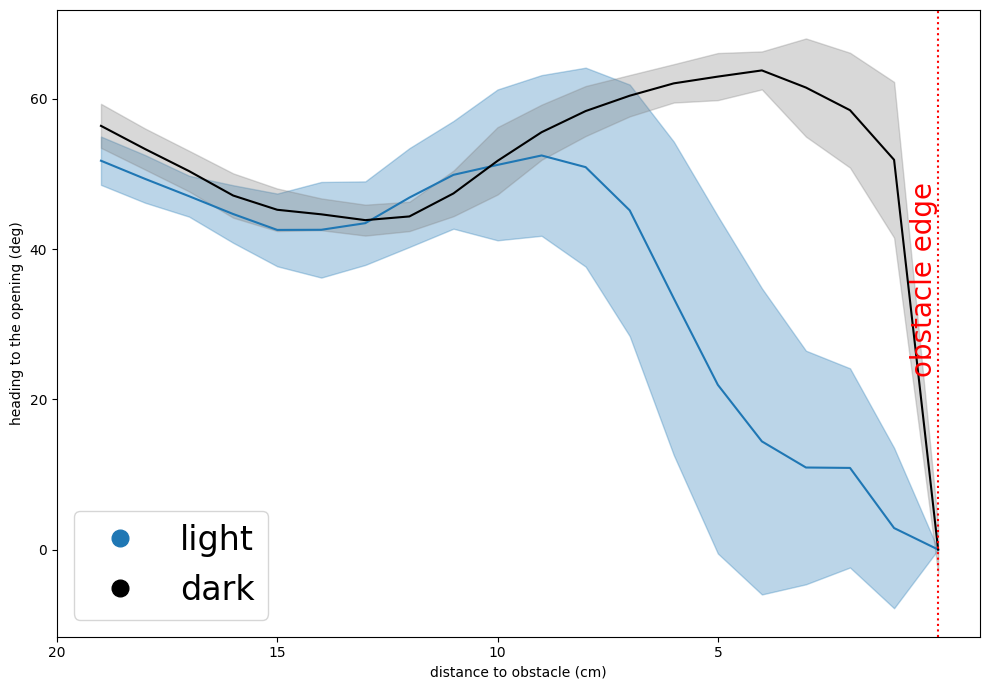

In [12]:
xnew =  np.arange(0, 20, 1)
xnew= np.flip(xnew)
fig,ax = plt.subplots(layout = 'tight',figsize = (10,7) )

ax.invert_xaxis()
data = pd.concat([joint])
data = drop_nans_in_columns(data,'obstacle_ind')
data = data[data.turn_to_obstacle == 'towards']
#zero_out_angle(data)
#ts_angle_to_open_corner(data)
#zero_out_angle(data)
light_medians = []
dark_medians = []
light_sd = []
dark_sd = []
for task,task_df in  data.groupby(['task']):
  
    rows = task_df.shape[0]
    angle_array = np.empty([rows,len(xnew)])
    angle_array[:] =np.nan 
    for i,row in enumerate(task_df.iterrows()):
        x = row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])].astype(float)
        y = row[1]['ts_zero_out_angle_to_corner'][:int(row[1]['obstacle_ind'])].astype(float)
        if sum(y) == 0:
            continue
        else:
            interpolater = interp1d(x,y,bounds_error=False)
            ynew = interpolater(xnew)
            angle_array[i] = ynew

    
    task_angle_median= np.nanmedian(angle_array,axis = 0)

 
    if task == 'oa':
        light_array = angle_array
        light_angle_median= np.nanmedian(angle_array,axis = 0)
        ax.plot(xnew,task_angle_median,c = 'tab:blue',alpha = 1)
    else:
        dark_array = angle_array
        dark_angle_median= np.nanmedian(angle_array,axis = 0)
        ax.plot(xnew,dark_angle_median,c = 'black',alpha = 1)

    for animal,animal_df in task_df.groupby(['date']):
        rows = animal_df.shape[0]
        angle_array = np.empty([rows,len(xnew)])
        angle_array[:] =np.nan 
        for i,row in enumerate(animal_df.iterrows()):
            x = row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])].astype(float)
            y = row[1]['ts_zero_out_angle_to_corner'][:int(row[1]['obstacle_ind'])].astype(float)
            if sum(y) == 0:
                continue
            else:
                interpolater = interp1d(x,y,bounds_error=False)
                ynew = interpolater(xnew)
                angle_array[i] = ynew
        animal_angle_median= np.nanmedian(angle_array,axis = 0)
        if animal_df.task.unique() == 'oa':
            light_medians.append(animal_angle_median)
        else:
            dark_medians.append(animal_angle_median)

light_medians = np.asarray(light_medians)
dark_medians = np.asarray(dark_medians)

for i in list(range(light_medians.shape[1])):
    sd = np.nanstd(light_medians[:,i])
    light_sd.append(sd)
light_sd = np.asarray(light_sd)

for i in list(range(dark_medians.shape[1])):
    sd = np.nanstd(dark_medians[:,i])
    dark_sd.append(sd)
dark_sd = np.asarray(dark_sd)

            






ax.fill_between(xnew, light_angle_median-light_sd, light_angle_median+light_sd, color='tab:blue', alpha=0.3, label='IQR')   
ax.fill_between(xnew, dark_angle_median-dark_sd, dark_angle_median+dark_sd, color='tab:grey', alpha=0.3, label='IQR')  
ax.set_xticks([20,15,10,5])    
ax.set_yticks([0,20,40,60])  
ax.set_ylabel('heading to the opening (deg)')
ax.set_xlabel('distance to obstacle (cm)')
ax.axvline(0, color='r', ls=':')
ax.text(0, ax.get_ylim()[1]/2,'obstacle edge', color='r', ha='right', va='center', rotation=90,fontsize=20)
   
markers = [plt.Line2D([0,0],[0,0],color=color, marker='o', linestyle='',markersize=12) for color in ['tab:blue','black']]
ax.legend(markers, ['light','dark'], numpoints=1,loc = 'lower left',fontsize=24)

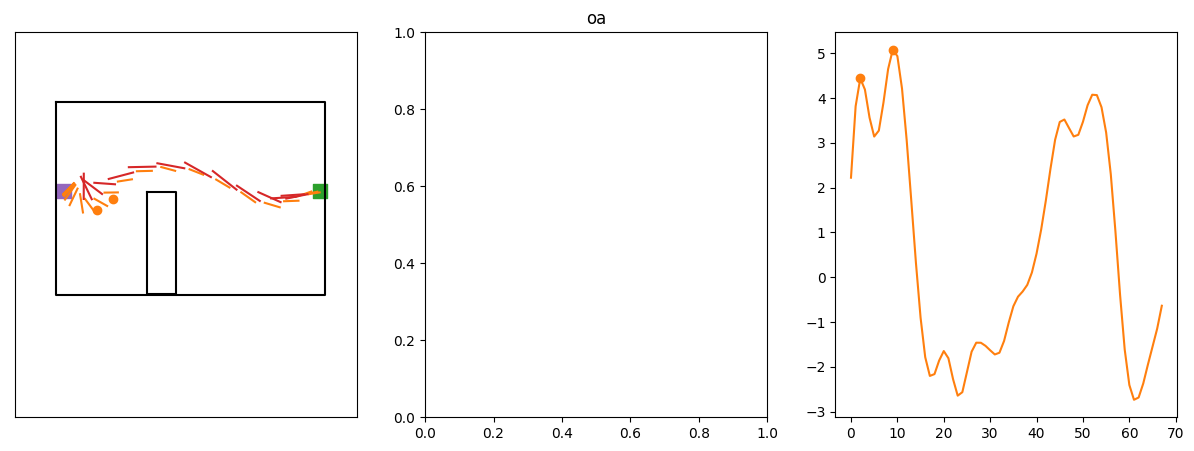

In [10]:
test1 = joint.sample(1)
#test1 = test1[test1.num_turn >= 3].sample(50)


for ind,row in test1.iterrows():
    
        
    fig,ax = plt.subplots(1,3,figsize=(15,5))
    ax[0].set_xticks([])
    ax[0].set_yticks([])
   
    


    trial_df = test1.loc[[ind]]
    plot_arena(test1,ax[0])
    plot_orginal_obstacle(trial_df,ax[0],int(row.obstacle_cluster))



   
    ax[1].set_title(str(row.task) )
 


    

  
    ax[0].plot((row.nose_x_cm[::5],row.spine_x_cm[::5]),(row.nose_y_cm[::5],row.spine_y_cm[::5]),color = 'tab:orange')
    ax[0].scatter((row.ts_nose_x_cm)[row.distance_at_head_turn_2_indexs.tolist()],(row.ts_nose_y_cm)[row.distance_at_head_turn_2_indexs.tolist()],color = 'tab:orange')
    ax[0].plot((row.ts_spine_x_cm[::5],row.ts_tailbase_x_cm[::5]),(row.ts_spine_y_cm[::5],row.ts_tailbase_y_cm[::5]),color = 'tab:red')
    ax[2].plot(row.head_angle_velocity,color = 'tab:orange')
    ax[2].scatter(row.distance_at_head_turn_2_indexs.tolist(),(row.head_angle_velocity)[row.distance_at_head_turn_2_indexs.tolist()],color = 'tab:orange')